# **Project 01**

## **Bài toán số 1 - Prediction with models**

**Cài đặt**

In [ ]:
# Mở rào các dòng bên dưới để chạy trên môi trường Linux hoặc Google Colab
# !pip uninstall -y dataproc-spark-connect -q 2>/dev/null
# !pip install -q pyspark==3.4.1
# !pip install -q findspark
# !pip install ydata-profiling
# !pip install synapseml==0.11.1
# !pip install pyvi
# !pip install gensim

import findspark
findspark.init()

**Khởi tạo spark session**

In [52]:
from pyspark.sql import SparkSession
spark = SparkSession.builder\
                    .master("local[*]")\
                    .appName('DL07_Group3_Project1')\
                    .config("spark.driver.memory", "140g")\
                    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:0.11.1,ml.dmlc:xgboost4j-spark_2.12:1.4.1")\
                    .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven")\
                    .getOrCreate()

CPUcores_num = spark.sparkContext.defaultParallelism

**Import thư viện**

In [53]:
import os, psutil, re, unicodedata, math, warnings, logging, builtins
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ydata_profiling import ProfileReport
from scipy import stats
from scipy.special import inv_boxcox
from functools import reduce
from itertools import combinations
from pyspark.sql.functions import round, count, col, lit, sum as spark_sum, isnan, when, udf, coalesce, rand, regexp_replace, skewness, kurtosis, mean, stddev, log, sqrt, exp, pow, min as spark_min
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType, StringType, FloatType, LongType, ArrayType
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import QuantileDiscretizer, VectorAssembler, RobustScaler, StandardScaler, MinMaxScaler, StringIndexer, OneHotEncoder, PCA, Tokenizer, HashingTF, IDF, Normalizer
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.linalg import VectorUDT, Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator
from synapse.ml.lightgbm import LightGBMRegressor
from xgboost.spark import SparkXGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import QuantileTransformer
from pyvi import ViTokenizer
from pyvi.ViTokenizer import tokenize
from bs4 import BeautifulSoup
from gensim import corpora, models, similarities




**Load dữ liệu lưu vào biến data frame**

In [54]:
# Load data
folder_path = 'Data'
df_csv = spark.read.csv(os.path.join(folder_path, "*.csv"), header=True, inferSchema=True, multiLine=True, escape='"')


In [55]:
# Sử dụng parquet & cache
df_csv.write.mode("overwrite").parquet("data_pq.parquet")
data = spark.read.parquet("data_pq.parquet") \
                .repartition(CPUcores_num) \
                .cache()
data.count()

8273

In [56]:
print(f"CPU: {psutil.cpu_percent(interval=1, percpu=True)} | RAM: {psutil.virtual_memory().percent}%")
print("Default parallelism của Spark:", spark.sparkContext.defaultParallelism)
print(f"Số lượng partition hiện tại là: {data.rdd.getNumPartitions()}")

CPU: [0.0, 1.0, 1.0, 2.0, 0.0, 1.0, 1.0, 0.0] | RAM: 7.0%
Default parallelism của Spark: 8
Số lượng partition hiện tại là: 8


**Xem thông tin chung dữ liệu**

In [57]:
data.printSchema()

root
 |-- tieu_de: string (nullable = true)
 |-- gia_ban: string (nullable = true)
 |-- don_gia: string (nullable = true)
 |-- dien_tich: string (nullable = true)
 |-- dia_chi: string (nullable = true)
 |-- mo_ta: string (nullable = true)
 |-- dien_thoai: string (nullable = true)
 |-- loai_hinh: string (nullable = true)
 |-- dien_tich_dat: string (nullable = true)
 |-- dien_tich_su_dung: string (nullable = true)
 |-- gia_m2: string (nullable = true)
 |-- giay_to_phap_ly: string (nullable = true)
 |-- so_phong_ngu: string (nullable = true)
 |-- so_phong_ve_sinh: string (nullable = true)
 |-- tong_so_tang: integer (nullable = true)
 |-- tinh_trang_noi_that: string (nullable = true)
 |-- huong_cua_chinh: string (nullable = true)
 |-- dac_diem: string (nullable = true)
 |-- chieu_ngang: string (nullable = true)
 |-- chieu_dai: string (nullable = true)
 |-- ma_can: string (nullable = true)
 |-- ten_phan_khu_lo: string (nullable = true)
 |-- bieu_do_gia: string (nullable = true)



**Xem thông tin mẫu**

In [58]:
data.show(10)

+--------------------+-------+---------------+---------+--------------------+--------------------+----------+--------------------+-------------+-----------------+---------------+---------------+------------+----------------+------------+-------------------+---------------+----------+-----------+---------+------+---------------+--------------------+
|             tieu_de|gia_ban|        don_gia|dien_tich|             dia_chi|               mo_ta|dien_thoai|           loai_hinh|dien_tich_dat|dien_tich_su_dung|         gia_m2|giay_to_phap_ly|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|  dac_diem|chieu_ngang|chieu_dai|ma_can|ten_phan_khu_lo|         bieu_do_gia|
+--------------------+-------+---------------+---------+--------------------+--------------------+----------+--------------------+-------------+-----------------+---------------+---------------+------------+----------------+------------+-------------------+---------------+----------+-----------+--

**Xử lý dữ liệu trùng --> đối với dữ liệu đã cho là các dòng không có dữ liệu trong quá trình crawl data**

In [59]:
data = data.distinct()
data.count()

7941

**Xử lý đơn vị tiền tệ**

In [60]:
def standardize_price(price_str):
    if not price_str: return None
    price_str = price_str.lower().replace(',', '.')
    # Trích xuất số
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", price_str)
    if not nums: return None
    val = float(nums[0])
    if 'tỷ' in price_str: return val
    if 'triệu' in price_str: return val / 1000
    return val

standardize_price_udf = F.udf(standardize_price, DoubleType())
data = data.withColumn("gia_ban", standardize_price_udf(F.col("gia_ban")))

**Chuyển đổi các cột có đơn vị tính về dạng chỉ có số để tính toán**\
Riêng 2 cột 'don_gia', 'gia_m2' chỉ xử lý tượng trưng vì sẽ drop vì lý do ở những bước dưới

In [61]:
columns_to_convert = [
    'gia_ban', 'don_gia', 'dien_tich', 'dien_tich_dat', 'dien_tich_su_dung', 'gia_m2', 'so_phong_ngu',
    'so_phong_ve_sinh', 'chieu_ngang', 'chieu_dai'
]
for col_name in columns_to_convert:
    # Clean the string by removing common non-numeric characters and units
    # and standardizing decimal separator (replace comma with dot).
    # The pattern '[^0-9,.]' will keep digits, commas, and dots.
    # Then, we replace commas with dots for decimal conversion.
    cleaned_col_expr = F.regexp_replace(col(col_name), '[^0-9,.]', '')
    cleaned_col_expr = F.regexp_replace(cleaned_col_expr, ',', '.')

    # Then cast to DoubleType. If conversion fails (e.g., empty string after cleaning), it becomes null.
    data = data.withColumn(col_name,
                           when(cleaned_col_expr.cast(DoubleType()).isNull(), None)
                           .otherwise(cleaned_col_expr.cast(DoubleType())))

data.show(3, truncate=True)

+--------------------+-------+-------+---------+--------------------+--------------------+----------+------------+-------------+-----------------+------+---------------+------------+----------------+------------+-------------------+---------------+----------+-----------+---------+------+---------------+--------------------+
|             tieu_de|gia_ban|don_gia|dien_tich|             dia_chi|               mo_ta|dien_thoai|   loai_hinh|dien_tich_dat|dien_tich_su_dung|gia_m2|giay_to_phap_ly|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|  dac_diem|chieu_ngang|chieu_dai|ma_can|ten_phan_khu_lo|         bieu_do_gia|
+--------------------+-------+-------+---------+--------------------+--------------------+----------+------------+-------------+-----------------+------+---------------+------------+----------------+------------+-------------------+---------------+----------+-----------+---------+------+---------------+--------------------+
|Bán nhà Thống Nhấ...|

**Kiểm tra và điền các dòng giá trị không hợp lệ của chiều ngang về null**

In [62]:
def clean_invalid_dimensions(df):
    # Tính toán diện tích tạm thời (chieu_ngang * chieu_dai)
    # Lưu ý: Nếu một trong hai cột là null, kết quả dien_tich_tmp sẽ tự động là null
    df = df.withColumn(
        "dien_tich_tmp",
        F.when(
            F.col("chieu_ngang").isNotNull() & F.col("chieu_dai").isNotNull(),
            F.col("chieu_ngang") * F.col("chieu_dai")
        ).otherwise(F.lit(0))
    )

    # Định nghĩa các điều kiện vi phạm
    # Điều kiện 1: chieu_ngang > dien_tich
    cond1 = F.col("chieu_ngang") > F.col("dien_tich")

    # Điều kiện 2: sai lệch diện tích > 0 (khi cả 3 cột đều NOT NULL)
    # abs(dien_tich - dien_tich_tmp) > 0
    cond2 = (F.col("chieu_ngang").isNotNull()) & \
            (F.col("chieu_dai").isNotNull()) & \
            (F.col("dien_tich").isNotNull()) & \
            (F.abs(F.col("dien_tich") - F.col("dien_tich_tmp")) > 0)

    # Sử dụng F.when để gán lại giá trị cho chieu_ngang
    # Nếu thỏa mãn cond1 HOẶC cond2 thì gán None (tương đương NaN), ngược lại giữ nguyên giá trị cũ
    df = df.withColumn(
        "chieu_ngang",
        F.when(cond1 | cond2, F.lit(None)).otherwise(F.col("chieu_ngang"))
    )

    # Loại bỏ cột tạm dien_tich_tmp để làm sạch DataFrame kết quả
    df = df.drop("dien_tich_tmp")

    return df

# Cách sử dụng:
data = clean_invalid_dimensions(data)

In [63]:
data.printSchema()

root
 |-- tieu_de: string (nullable = true)
 |-- gia_ban: double (nullable = true)
 |-- don_gia: double (nullable = true)
 |-- dien_tich: double (nullable = true)
 |-- dia_chi: string (nullable = true)
 |-- mo_ta: string (nullable = true)
 |-- dien_thoai: string (nullable = true)
 |-- loai_hinh: string (nullable = true)
 |-- dien_tich_dat: double (nullable = true)
 |-- dien_tich_su_dung: double (nullable = true)
 |-- gia_m2: double (nullable = true)
 |-- giay_to_phap_ly: string (nullable = true)
 |-- so_phong_ngu: double (nullable = true)
 |-- so_phong_ve_sinh: double (nullable = true)
 |-- tong_so_tang: integer (nullable = true)
 |-- tinh_trang_noi_that: string (nullable = true)
 |-- huong_cua_chinh: string (nullable = true)
 |-- dac_diem: string (nullable = true)
 |-- chieu_ngang: double (nullable = true)
 |-- chieu_dai: double (nullable = true)
 |-- ma_can: string (nullable = true)
 |-- ten_phan_khu_lo: string (nullable = true)
 |-- bieu_do_gia: string (nullable = true)



**Kiểm tra biến numerical mang giá trị 0 hoặc nhỏ hơn 0 là các giá trị invalid**

In [64]:
data.select([spark_sum((col(c) <= 0).cast('int')).alias(c) for c in data.columns if data.schema[c].dataType.typeName() in ("double", "integer")]).show()

+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+
|gia_ban|don_gia|dien_tich|dien_tich_dat|dien_tich_su_dung|gia_m2|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|chieu_ngang|chieu_dai|
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+
|      0|      0|        0|            0|                0|     0|           0|               0|           0|          0|        0|
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+



**Kiểm tra Null**

In [65]:
data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-------+---------+-------+-----+----------+---------+-------------+-----------------+------+---------------+------------+----------------+------------+-------------------+---------------+--------+-----------+---------+------+---------------+-----------+
|tieu_de|gia_ban|don_gia|dien_tich|dia_chi|mo_ta|dien_thoai|loai_hinh|dien_tich_dat|dien_tich_su_dung|gia_m2|giay_to_phap_ly|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|ma_can|ten_phan_khu_lo|bieu_do_gia|
+-------+-------+-------+---------+-------+-----+----------+---------+-------------+-----------------+------+---------------+------------+----------------+------------+-------------------+---------------+--------+-----------+---------+------+---------------+-----------+
|      1|      2|      2|        2|      0|    2|      3997|        2|            2|             4195|     2|            501|           2|            1978|        2453|               3519

**Vẽ biểu đồ tương quan để xét tính đa cộng tuyến**\
Nhận xét:
- 'chieu_dai' có tương quan mạnh với 'dien_tich_dat' (0.76) -> cần drop cột 'chieu_dai' để tránh đa cộng tuyến
- Tương tự cần drop cột 'so_phong_ve_sinh', giữ lại 'so_phong_ngu', vì 'so_phong_ngu' không có Null

In [66]:
def visualize_correlation(df):
    # Now identify actual numeric columns after preprocessing and casting
    numeric_cols = [c for c, dtype in df.dtypes if dtype == 'double' or dtype == 'int']

    # Check the number of non-null values in the intended numeric columns after conversion
    print("Non-null counts for intended numeric columns after conversion:")
    df.select([count(when(col(c).isNull(), c)).alias(c) for c in numeric_cols]).show()

    # Also show a sample of the transformed data for these columns
    print("Sample of transformed numeric columns:")
    df.select(*numeric_cols).show(5, truncate=False)

    # Proceed with correlation if there are actually numeric columns and data
    if not numeric_cols:
        print("No numeric columns found after casting. Correlation cannot be computed.")
    else:
        # Filter out rows where all identified numeric columns are null before assembling
        # We only drop rows that have nulls in *any* of the `numeric_cols`.
        # However, if there are too many nulls, this can still result in an empty DataFrame.
        data_for_correlation = df.na.drop(subset=numeric_cols)

        # Check if data_for_correlation is empty after dropping NaNs
        if data_for_correlation.count() == 0:
            print("No data remaining after dropping nulls in numeric columns. Correlation cannot be computed.")
        else:
            # Assemble numeric columns into a single vector column
            # Change outputCol to avoid conflict
            assembler = VectorAssembler(inputCols=numeric_cols, outputCol="temp_correlation_features")
            data_vector = assembler.transform(data_for_correlation)

            # Calculate the correlation matrix
            correlation_matrix = Correlation.corr(data_vector, "temp_correlation_features").head()[0].toArray()

            # For better display, convert it to a Pandas DataFrame
            corr_df = pd.DataFrame(correlation_matrix, columns=numeric_cols, index=numeric_cols)

            # Visualize
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
            plt.title('Correlation Matrix of Numeric Features')
            plt.show()

Non-null counts for intended numeric columns after conversion:
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+
|gia_ban|don_gia|dien_tich|dien_tich_dat|dien_tich_su_dung|gia_m2|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|chieu_ngang|chieu_dai|
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+
|      2|      2|        2|            2|             4195|     2|           2|            1978|        2453|       5573|     1987|
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+

Sample of transformed numeric columns:
+-------+-------+---------+-------------+-----------------+------+------------+----------------+------------+-----------+---------+
|gia_ban|don_gia|dien_tich|dien_tich_dat|dien_tich_su_dung|gia_m2|so_phong_ngu|so_phong_ve_sinh|tong_so_t

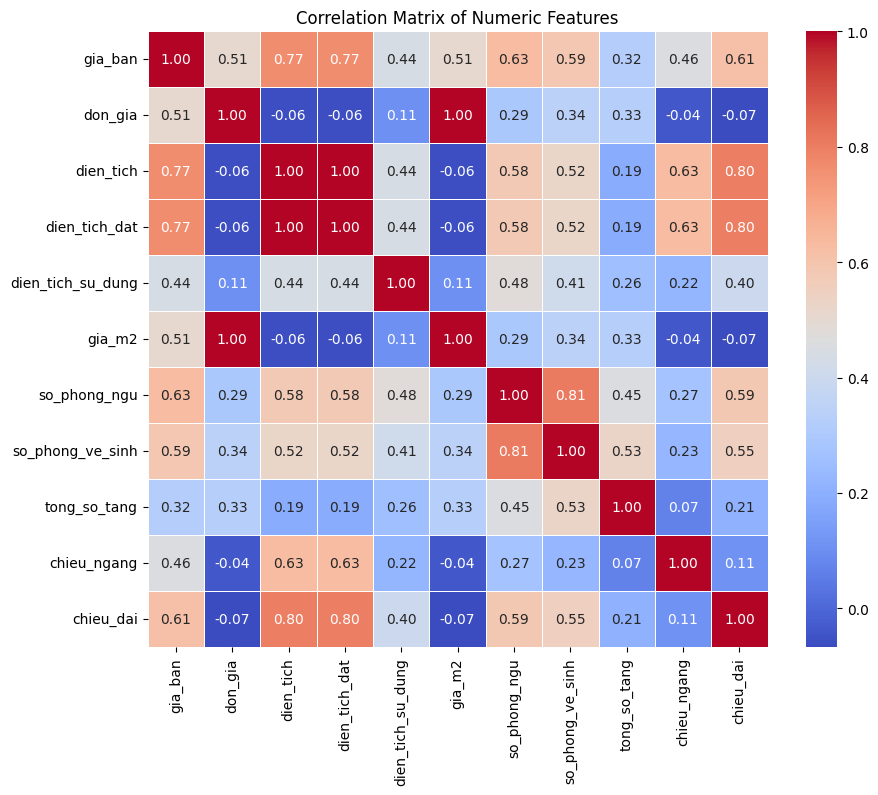

In [67]:
visualize_correlation(data)

**Drop các cột không có ý nghĩa thống kê và có sự tương quan, một số cột khác sẽ được drop sau khi trích xuất thông tin, vd: 'tieu_de', 'mo_ta', 'dia_chi', 'chieu_dai'**
- Đơn giá = giá bán/ diện tích đất
- Diện tích = diện tích đất
- Chiều dài: tương quan với Diện tích đất
- Số phòng vệ sinh tương quan với Số phòng ngủ
- Giá m2 = đơn giá
- Điện thoại, mã căn, tên phân khu/lô, biểu đồ giá: không có ý nghĩa thống kê

In [68]:
data = data.drop(*['don_gia', 'dien_tich', 'so_phong_ve_sinh', 'gia_m2', 'dien_thoai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia'])
data.show(3, truncate=True)

+--------------------+-------+--------------------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+----------+-----------+---------+
|             tieu_de|gia_ban|             dia_chi|               mo_ta|   loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|  dac_diem|chieu_ngang|chieu_dai|
+--------------------+-------+--------------------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+----------+-----------+---------+
|Bán nhà Thống Nhấ...|    4.2|Đường Thống Nhất,...|THỐNG NHẤT - PHƯỜ...|Nhà ngõ, hẻm|         48.0|             null|       Đã có sổ|         2.0|           2|               null|           null|      null|       null|     null|
|Biệt thự Gò Vấp n...|   12.8|Đường Quang Trung...|BIỆT THỰ GÒ VẤP N...|Nhà ngõ, hẻm

**Thêm feature là 2 cột địa chỉ cũ, địa chỉ mới từ cột địa chỉ, vì địa chỉ phản ánh khu vực mặt bằng giá nên có liên quan đến giá nhà, vd nhà quận 1 thường đắt hơn nhà các quận khác, sau đó drop cột địa chi vì không còn nhu cầu phân tích thống kê**

In [69]:
# 1. Trích xuất dia_chi_cu (Lấy đoạn "Phường..., Quận..." trước dấu ngoặc đơn)
# Regex: (Phường\s+[^,]+,\s+Quận\s+[^,]+)
# Ý nghĩa: Tìm chữ "Phường", lấy các ký tự đến dấu phẩy, rồi đến "Quận" và các ký tự tiếp theo.
data = data.withColumn(
    "dia_chi_cu",
    F.regexp_extract(F.col("dia_chi"), r"(Phường\s+[^,]+,\s+Quận\s+[^,]+)", 1)
)

# 2. Trích xuất dia_chi_moi (Lấy chữ "Phường..." nằm bên trong dấu ngoặc đơn cuối câu)
# Regex: \((Phường\s+[^,]+)
# Ý nghĩa: Tìm dấu ngoặc đơn mở '(', sau đó bắt đầu lấy cụm "Phường..." cho đến khi gặp dấu phẩy.
data = data.withColumn(
    "dia_chi_moi",
    F.regexp_extract(F.col("dia_chi"), r"\((Phường\s+[^,]+)", 1)
)

if data.filter((F.col("dia_chi_cu")=='') | (F.col("dia_chi_moi")=='')).count() != 0:
    dia_chi_cols = ['dia_chi_cu', 'dia_chi_moi']
    for col_name in dia_chi_cols:
        data = data.withColumn(
            col_name,
            F.when(F.col(col_name) == '', 'Chưa xác định').otherwise(F.col(col_name))
        )
# 3. Hiển thị kết quả kiểm tra
data = data.drop('dia_chi')
data.show(3, truncate=True)

+--------------------+-------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+----------+-----------+---------+--------------------+--------------------+
|             tieu_de|gia_ban|               mo_ta|   loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|  dac_diem|chieu_ngang|chieu_dai|          dia_chi_cu|         dia_chi_moi|
+--------------------+-------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+----------+-----------+---------+--------------------+--------------------+
|Bán nhà Thống Nhấ...|    4.2|THỐNG NHẤT - PHƯỜ...|Nhà ngõ, hẻm|         48.0|             null|       Đã có sổ|         2.0|           2|               null|           null|      null|       null|     null|Phường 11, Quận G...|Phường Thông Tây Hội|


**Xử lý Null**

**Chúng ta sẽ xử lý theo thứ tự lần lượt như sau:**
- 'loai_hinh', 'dien_tich_dat', 'so_phong_ngu': xử lý null bằng cách xóa 2 dòng dữ liệu invalid
- 'tong_so_tang': được trích xuất thông tin từ 2 cột 'tieu_de' và 'mo_ta'
- 'dien_tich_su_dung' có mối tương quan với 'dien_tich_dat' và 'tong_so_tang', nên dùng model Linear Regression để dự đoán
- 'chieu_ngang' được xử lý lần lượt qua 2 phương án:\
\+ PA1: Tính dựa vào 'dien_tich_dat' và 'chieu_dai' sẵn có: chieu_ngang = dien_tich_dat/chieu_dai\
\+ PA2: Tính dựa vào median / mean tỷ lệ thực tế trong dữ liệu
→ Tính ratio = chieu_ngang / chieu_dai (hoặc ngược lại) từ các hàng có cả 2 cột không null → lấy median(ratio) → chieu_ngang ≈ sqrt(dien_tich_dat / median_ratio)
- 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem': tỉ lệ null thấp --> xử lý null bằng cách điền giá trị 'Chưa xác định', 'Hiện trạng khác'
- 'huong_cua_chinh': tỉ lệ null cao, nhưng do yếu tố ngẫu nhiên của hướng --> dùng phương pháp random

**Kiểm tra và xử lý 2 dòng dữ liệu invalid, 2 dòng này làm tăng số dòng null của tất cả các cột**

In [70]:
data.filter(col('dien_tich_dat').isNull()).show()

+--------------------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+-------------+-------------+
|             tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|   dia_chi_cu|  dia_chi_moi|
+--------------------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+-------------+-------------+
|                null|   null| null|     null|         null|             null|           null|        null|        null|               null|           null|    null|       null|     null|Chưa xác định|Chưa xác định|
|Bad gateway Error...|   null| null|     null|         null|             null|           null|        null|        null|               n

In [71]:
# Xóa null các dòng invalid
data = data.filter(~(col('dien_tich_dat').isNull()))
data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+
|      0|      0|    0|        0|            0|             4193|            499|           0|        2451|               3517|           6621|    2744|       5571|     1985|         0|          0|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+



**Xử lý null cho cột 'tong_so_tang', phương án như sau:**
- Dùng regex để nhận diện số lầu, lửng hoặc tầng
- Ưu tiên nếu có thông tin số tầng thì lấy số tầng trực tiếp từ text
- Tìm thông tin lầu, lửng để suy ra số tầng = lầu + lửng + 1
- Nếu không có thông tin lầu, lửng hoặc số tầng thì mặc định số tầng = 1

In [72]:
# --- Định nghĩa hàm xử lý số tầng (XỬ LÝ CẢ TỪ VIẾT SAI) ---
def extract_floor_count(text):

    if not text or not isinstance(text, str):
        return None

    text_lower = text.lower()

    # --- Định nghĩa các biến thể của từ khóa ---
    # Các biến thể của "lầu"
    lau_variants = ['lầu', 'lẩu', 'làu', 'lâù', 'lâu']
    # Các biến thể của "lửng"
    lung_variants = ['lửng', 'lững', 'lừng', 'lữn', 'lưng', 'lủng']

    # Tạo pattern cho từng loại
    lau_pattern = '|'.join(lau_variants)
    lung_pattern = '|'.join(lung_variants)

    # --- Ưu tiên: Tìm theo cấu trúc "x tầng" (đã bao gồm trệt) ---
    tang_pattern = r'(\d+)\s*tầng'
    tang_matches = re.findall(tang_pattern, text_lower)

    if tang_matches:
        # Nếu tìm thấy "x tầng", trả về số đó (đã bao gồm trệt)
        return int(tang_matches[0])

    # --- Tìm theo cấu trúc "x lầu" với các biến thể ---
    floor_pattern = fr'(\d+)\s*({lau_pattern})'
    mezz_pattern = fr'(\d+)\s*({lung_pattern})'

    # Tìm tất cả các kết quả
    floor_matches = re.findall(floor_pattern, text_lower)
    mezz_matches = re.findall(mezz_pattern, text_lower)

    # Lấy giá trị DUY NHẤT (chỉ lấy phần số, bỏ qua từ khóa)
    floor_numbers = set([match[0] for match in floor_matches])
    mezz_numbers = set([match[0] for match in mezz_matches])

    # Kiểm tra sự tồn tại của các từ khóa (không cần số)
    has_lau = any(variant in text_lower for variant in lau_variants)
    has_lung = any(variant in text_lower for variant in lung_variants)

    # Nếu có dấu hiệu của cấu trúc "lầu/lửng"
    if floor_numbers or mezz_numbers or has_lau or has_lung:
        # Luôn cộng 1 cho tầng trệt
        total_floors = 1

        # Cộng dồn số tầng từ các số tìm được
        for f in floor_numbers:
            total_floors += int(f)
        for m in mezz_numbers:
            total_floors += int(m)

        # Xử lý trường hợp có từ khóa nhưng không có số
        # Nếu có từ "lầu" mà không có số nào, mặc định cộng thêm 1
        if has_lau and not floor_numbers:
            total_floors += 1
        # Nếu có từ "lửng" mà không có số nào, mặc định cộng thêm 1
        if has_lung and not mezz_numbers:
            total_floors += 1

        return total_floors

    # Không tìm thấy thông tin
    return None

# --- Đăng ký UDF ---
extract_floor_udf = udf(extract_floor_count, IntegerType())

# --- Tạo hai cột mới 'mo_ta_so_tang' và 'tieu_de_so_tang' ---
data = data.withColumn("mo_ta_so_tang", extract_floor_udf(col("mo_ta"))) \
                   .withColumn("tieu_de_so_tang", extract_floor_udf(col("tieu_de")))

# --- Imputing ---
# Case 1: Cả 2 cột 'tieu_de_so_tang', 'mo_ta_so_tang' đều null
data = data.withColumn("tong_so_tang",
    when(col("tong_so_tang").isNull() & col("tieu_de_so_tang").isNull() & col("mo_ta_so_tang").isNull(), 1)
    .otherwise(col("tong_so_tang"))
)

# Case 2: Ít nhất một trong 2 cột 'tieu_de_so_tang', 'mo_ta_so_tang' khác null
data = data.withColumn("tong_so_tang",
    when(col("tong_so_tang").isNull(),
        coalesce(
            when(col("mo_ta_so_tang").isNotNull() & (col("mo_ta_so_tang") > 0), col("mo_ta_so_tang")),
            when(col("tieu_de_so_tang").isNotNull() & (col("tieu_de_so_tang") > 0), col("tieu_de_so_tang"))
        )
    )
    .otherwise(col("tong_so_tang"))
)

# Verify the changes
data.select("tieu_de", "tieu_de_so_tang", "mo_ta", "mo_ta_so_tang", "tong_so_tang").show(10, truncate=100)


+-----------------------------------------------------------------------+---------------+----------------------------------------------------------------------------------------------------+-------------+------------+
|                                                                tieu_de|tieu_de_so_tang|                                                                                               mo_ta|mo_ta_so_tang|tong_so_tang|
+-----------------------------------------------------------------------+---------------+----------------------------------------------------------------------------------------------------+-------------+------------+
|           Bán nhà Thống Nhất, Gò Vấp, DT 48m2, 2 tầng - Chỉ nhỉnh 4 tỷ|              2|THỐNG NHẤT - PHƯỜNG THÔNG TÂY HỘI (PHƯỜNG 11) - GÒ VẤP - 48m2 - CHỈ 4 TỶ 2 CÒN TL\n+ Diện tích 48...|            2|           2|
| Biệt thự Gò Vấp ngang 8.3M cho thuê CHDV dòng tiền 70tr/th, 12.X tỷ TL|           null|BIỆT THỰ GÒ VẤP NGANG 8.3M - ĐƯỜNG XE T

**Kiểm tra và clean data đối với 'tong_so_tang' lớn hơn 8, vì nhà phố quy định thường không quá 8 (Theo Quyết định 135/2007/QĐ-UBND về kiến trúc nhà liên kế trong khu đô thị hiện hữu của TPHCM)**

In [73]:
data.where(col('tong_so_tang') > 8).count()

15

In [74]:
data = data.where(col('tong_so_tang') <= 8)

In [75]:
print(f"Số dòng còn lại: {data.count()}")

Số dòng còn lại: 7924


**Xử lý null cho cột 'dien_tich_su_dung'**

In [76]:
# Define conditions for training_data
training_condition = (
    col("dien_tich_su_dung").isNotNull() &
    col("dien_tich_dat").isNotNull() &
    col("tong_so_tang").isNotNull()
)

# Define conditions for predict_data
predict_condition = (
    col("dien_tich_su_dung").isNull() &
    col("dien_tich_dat").isNotNull() &
    col("tong_so_tang").isNotNull()
)

# 1. Create training_data
training_data = data.filter(training_condition)

# 2. Create predict_data
predict_data = data.filter(predict_condition)

# 3. Display counts to verify the split
print(f"Total rows in original data: {data.count()}")
print(f"Rows in training_data: {training_data.count()}")
print(f"Rows in predict_data: {predict_data.count()}")

# Optional: Verify sum of counts equals original total
expected_total = training_data.count() + predict_data.count()
print(f"Sum of split data rows: {expected_total}")

# Define the features to be used for the model
feature_cols = ["dien_tich_dat", "tong_so_tang"]

# Create a VectorAssembler to combine feature columns into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transform training_data and predict_data
training_data_assembled = assembler.transform(training_data)
predict_data_assembled = assembler.transform(predict_data)

# Display the schema of the assembled data to verify the new 'features' column
print("\nSchema of training_data_assembled:")
training_data_assembled.printSchema()

print("\nSchema of predict_data_assembled:")
predict_data_assembled.printSchema()

# Initialize LinearRegression model
lr = LinearRegression(featuresCol="features", labelCol="dien_tich_su_dung")

# Train the model on training_data_assembled
lr_model = lr.fit(training_data_assembled)

# Make predictions on predict_data_assembled
predictions = lr_model.transform(predict_data_assembled)

# Cap negative predictions at dien_tich_dat for dien_tich_su_dung
predictions = predictions.withColumn(
    "predicted_dien_tich_su_dung",
    when(col("prediction") < 0, col("dien_tich_dat")).otherwise(col("prediction"))
)

# Display sample of predictions
print("Sample of predictions for dien_tich_su_dung:")
predictions.select("dien_tich_dat", "tong_so_tang", "dien_tich_su_dung", "predicted_dien_tich_su_dung").show(10)

# Select necessary columns from predictions (original columns + predicted_dien_tich_su_dung)
# Ensure to drop the 'features' and 'prediction' columns generated by the model
predicted_values = predictions.select(
    *[col(c) for c in predict_data.columns],
    col("predicted_dien_tich_su_dung")
)

# Fill dien_tich_su_dung in predict_data with predicted values
imputed_predict_data = predicted_values.withColumn(
    "dien_tich_su_dung",
    coalesce(col("dien_tich_su_dung"), col("predicted_dien_tich_su_dung"))
).drop("predicted_dien_tich_su_dung") # Drop the temporary predicted column

# Union all dataframes back together
# First, align columns if necessary (though they should be consistent if split correctly)
final_data = training_data.unionByName(imputed_predict_data)

# Update the 'data' DataFrame with the imputed values
data = final_data.drop("predicted_dien_tich_su_dung")

# Verify the number of remaining nulls in 'dien_tich_su_dung' in the updated 'data' DataFrame
print("Null count for 'dien_tich_su_dung' in updated 'data' DataFrame:")
data.select(count(when(col("dien_tich_su_dung").isNull(), "dien_tich_su_dung"))).show()


Total rows in original data: 7924
Rows in training_data: 3737
Rows in predict_data: 4187
Sum of split data rows: 7924

Schema of training_data_assembled:
root
 |-- tieu_de: string (nullable = true)
 |-- gia_ban: double (nullable = true)
 |-- mo_ta: string (nullable = true)
 |-- loai_hinh: string (nullable = true)
 |-- dien_tich_dat: double (nullable = true)
 |-- dien_tich_su_dung: double (nullable = true)
 |-- giay_to_phap_ly: string (nullable = true)
 |-- so_phong_ngu: double (nullable = true)
 |-- tong_so_tang: integer (nullable = true)
 |-- tinh_trang_noi_that: string (nullable = true)
 |-- huong_cua_chinh: string (nullable = true)
 |-- dac_diem: string (nullable = true)
 |-- chieu_ngang: double (nullable = true)
 |-- chieu_dai: double (nullable = true)
 |-- dia_chi_cu: string (nullable = true)
 |-- dia_chi_moi: string (nullable = true)
 |-- mo_ta_so_tang: integer (nullable = true)
 |-- tieu_de_so_tang: integer (nullable = true)
 |-- features: vector (nullable = true)


Schema of pr

In [77]:
data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
|      0|      0|    0|        0|            0|                0|            498|           0|           0|               3512|           6609|    2742|       5562|     1982|         0|          0|         1030|           4302|
+-------+-------+-----+---------+-------------+-----------------+---------------+-------

In [78]:
data.filter(F.col('chieu_ngang') < 2).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+



**Xử lý null cho cột 'chieu_ngang' --> PA1**

In [79]:
data = data.withColumn(
    "chieu_ngang",
    when(
        # Điều kiện giống Pandas
        col("dien_tich_dat").isNotNull() &
        col("chieu_ngang").isNull() &
        col("chieu_dai").isNotNull() &
        (col("chieu_dai") > 0) &
        (col("dien_tich_dat") > 0),
        col("dien_tich_dat") / col("chieu_dai")
    ).otherwise(col("chieu_ngang")) # Giữ nguyên giá trị cũ (bao gồm cả null cũ nếu ko thỏa dk)
)

data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+
|      0|      0|    0|        0|            0|                0|            498|           0|           0|               3512|           6609|    2742|       1840|     1982|         0|          0|         1030|           4302|
+-------+-------+-----+---------+-------------+-----------------+---------------+-------

In [80]:
print(f"Số dòng còn lại: {data.count()}")

Số dòng còn lại: 7924


**Xử lý null cho cột 'chieu_ngang' --> PA2**

In [81]:
# Bước 1: Tính tỷ lệ ngang / dài từ các hàng có dữ liệu
df_valid = data.filter(
    F.col("chieu_ngang").isNotNull() & F.col("chieu_dai").isNotNull() &
    (F.col("chieu_dai") > 0)
).withColumn("ratio_ngang_dai", F.col("chieu_ngang") / F.col("chieu_dai"))

# Tính median ratio
median_ratio = df_valid.agg(F.expr('percentile_approx(ratio_ngang_dai, 0.5)').alias('median_ratio')).collect()[0]['median_ratio']

if median_ratio is None or median_ratio <= 0:
    median_ratio = 0.3          # fallback: giả định ngang ≈ dài * 0.3 (tức dài gấp ~3.3 lần ngang)

# Bước 2: Impute cho các hàng thiếu cả ngang + dài, nhưng có dien_tich_dat
data = data.withColumn(
    "chieu_ngang_imputed",
    F.when(
        (F.col("chieu_ngang").isNull()) & (F.col("chieu_dai").isNull()) & F.col("dien_tich_dat").isNotNull(),
        F.sqrt(F.col("dien_tich_dat") / median_ratio)
    ).otherwise(F.col("chieu_ngang"))
)

data = data.withColumn(
    "chieu_dai_imputed",
    F.when(
        (F.col("chieu_ngang").isNull()) & (F.col("chieu_dai").isNull()) & F.col("dien_tich_dat").isNotNull(),
        F.col("dien_tich_dat") / F.col("chieu_ngang_imputed")
    ).otherwise(F.col("chieu_dai"))
)

# Nếu muốn dùng chung một cột (overwrite gốc)
data = data.withColumn("chieu_ngang", F.coalesce(F.col("chieu_ngang"), F.col("chieu_ngang_imputed")))
data = data.withColumn("chieu_dai",   F.coalesce(F.col("chieu_dai"),   F.col("chieu_dai_imputed")))

data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|chieu_ngang_imputed|chieu_dai_imputed|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|      0|      0|    0|        0|            0|                0|            498|           0|           0|               3512|           6609|    2742|          0|      142|         0|          0|     

In [82]:
data.filter(F.col('chieu_ngang') == data.agg(F.min(F.col('chieu_ngang'))).collect()[0][0]).show()

+-------+-------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+--------------------+---------+--------------------+-------------------+-------------+---------------+--------------------+-----------------+
|tieu_de|gia_ban|               mo_ta|   loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|         chieu_ngang|chieu_dai|          dia_chi_cu|        dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang| chieu_ngang_imputed|chieu_dai_imputed|
+-------+-------+--------------------+------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+--------------------+---------+--------------------+-------------------+-------------+---------------+--------------------+-----------------+
|BÁN NHÀ|   12.5|Tôi cần bán nhà ,...|Nhà ngõ, hẻm|        121.0

In [83]:
data.filter(F.col('chieu_ngang') < 2).show()

+--------------------+-------+--------------------+--------------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+---------------+--------------------+---------+--------------------+--------------------+-------------+---------------+--------------------+-----------------+
|             tieu_de|gia_ban|               mo_ta|           loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|       dac_diem|         chieu_ngang|chieu_dai|          dia_chi_cu|         dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang| chieu_ngang_imputed|chieu_dai_imputed|
+--------------------+-------+--------------------+--------------------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+---------------+--------------------+---------+--------------------+--------------------+-------------+---------------+-----------------

**Xử lý null cho các cột 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem'**

In [84]:
data = data.fillna({'giay_to_phap_ly': 'Chưa xác định',
                    'tinh_trang_noi_that': 'Chưa xác định',
                    'dac_diem': 'Hiện trạng khác'})

data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|chieu_ngang_imputed|chieu_dai_imputed|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|      0|      0|    0|        0|            0|                0|              0|           0|           0|                  0|           6609|       0|          0|      142|         0|          0|     

**Xử lý null cho cột 'huong_cua_chinh'**

In [85]:
def impute_with_distribution(df, col='huong_cua_chinh', random_state=42):
    """
    Điền null bằng random sample theo distribution thực tế - thuần PySpark.
    """
    # Lấy distribution từ các giá trị không null
    value_counts = (
        df.filter(F.col(col).isNotNull())
          .groupBy(col)
          .count()
    )

    total = df.filter(F.col(col).isNotNull()).count()

    # Tạo bảng xác suất tích lũy (CDF)
    value_counts = value_counts.withColumn("prob", F.col("count") / total)

    # Collect về driver (nhỏ - chỉ 8 giá trị hướng)
    dist = value_counts.select(col, "prob").collect()
    values = [row[col] for row in dist]
    probs  = [row["prob"] for row in dist]

    # Tạo UDF dùng numpy seed cố định
    broadcast_vals  = df.sparkSession.sparkContext.broadcast(values)
    broadcast_probs = df.sparkSession.sparkContext.broadcast(probs)

    @F.udf(StringType())
    def random_fill(existing_val):
        if existing_val is not None:
            return existing_val
        rng = np.random.default_rng()  # mỗi partition tự seed
        return str(rng.choice(
            broadcast_vals.value,
            p=broadcast_probs.value
        ))

    return df.withColumn(col, random_fill(F.col(col)))

data = impute_with_distribution(data)

data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()


+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|tieu_de|gia_ban|mo_ta|loai_hinh|dien_tich_dat|dien_tich_su_dung|giay_to_phap_ly|so_phong_ngu|tong_so_tang|tinh_trang_noi_that|huong_cua_chinh|dac_diem|chieu_ngang|chieu_dai|dia_chi_cu|dia_chi_moi|mo_ta_so_tang|tieu_de_so_tang|chieu_ngang_imputed|chieu_dai_imputed|
+-------+-------+-----+---------+-------------+-----------------+---------------+------------+------------+-------------------+---------------+--------+-----------+---------+----------+-----------+-------------+---------------+-------------------+-----------------+
|      0|      0|    0|        0|            0|                0|              0|           0|           0|                  0|              0|       0|          0|      142|         0|          0|     

**Xử lý khoảng trắng cho giá trị trong các cột category để tránh lỗi khi chạy thuật toán**

In [86]:
def sanitize_string(s):
    if s is None:
        return None

    # 1. Chuyển về chữ thường (Lower case)
    s = s.lower()

    # 2. Loại bỏ dấu tiếng Việt
    # Chuẩn hóa Unicode để tách dấu
    s = unicodedata.normalize('NFKD', s)
    # Loại bỏ các ký tự dấu
    s = "".join([c for c in s if not unicodedata.combining(c)])
    # Xử lý riêng chữ đ/Đ
    s = s.replace('đ', 'd').replace('Đ', 'D')

    # 3. Thay thế ký tự đặc biệt và khoảng trắng thành dấu gạch dưới
    # Loại bỏ các ký tự không phải chữ cái latin hoặc số
    s = re.sub(r'[^\w\s]', '_', s)
    # Thay thế khoảng trắng và các dấu phân cách bằng gạch dưới
    s = re.sub(r'[\s,:\\[\]{}]+', '_', s)

    # 4. Dọn dẹp dấu gạch dưới thừa
    s = re.sub(r'_+', '_', s) # Thay nhiều gạch dưới liên tiếp bằng 1 cái
    s = s.strip('_')          # Xóa gạch dưới ở đầu và cuối chuỗi

    return s

# Đăng ký UDF
sanitize_udf = udf(sanitize_string, StringType())

# Danh sách các cột phân loại cần xử lý
categorical_cols = [
    'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
    'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi'
]

# Áp dụng cho tất cả cột trong danh sách (nếu cột đó tồn tại trong dataframe)
for col_name in categorical_cols:
    if col_name in data.columns:
        data = data.withColumn(col_name, sanitize_udf(data[col_name]))

# Kiểm tra mẫu dữ liệu sau khi làm sạch
print("Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:")
data.select([c for c in categorical_cols if c in data.columns]).show(5, truncate=False)

Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:
+--------------------+---------------+-------------------+---------------+---------------+-------------------------+--------------------+
|loai_hinh           |giay_to_phap_ly|tinh_trang_noi_that|huong_cua_chinh|dac_diem       |dia_chi_cu               |dia_chi_moi         |
+--------------------+---------------+-------------------+---------------+---------------+-------------------------+--------------------+
|nha_ngo_hem         |da_co_so       |noi_that_day_du    |nam            |hien_trang_khac|phuong_11_quan_go_vap    |phuong_thong_tay_hoi|
|nha_ngo_hem         |da_co_so       |chua_xac_dinh      |tay_bac        |nha_no_hau     |phuong_7_quan_binh_thanh |phuong_gia_dinh     |
|nha_ngo_hem         |da_co_so       |noi_that_cao_cap   |dong_nam       |hien_trang_khac|phuong_27_quan_binh_thanh|phuong_binh_quoi    |
|nha_mat_pho_mat_tien|da_co_so       |hoan_thien_co_ban  |dong_bac       |nha_no_hau     |phuong_5_quan_go_vap    

**Copy data cho project 1**

In [87]:
data = data.select('tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'tong_so_tang', 'so_phong_ngu', \
                   'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi', 'gia_ban')

**Copy data cho project 2 (chưa xử lý outlier, skewness)**

In [88]:
data_pr2_1 = data

**Kiểm tra lại dữ liệu**

In [89]:
data.show(5)

+--------------------+--------------------+-------------+-----------------+------------------+------------+------------+--------------------+---------------+-------------------+---------------+---------------+--------------------+--------------------+-------+
|             tieu_de|               mo_ta|dien_tich_dat|dien_tich_su_dung|       chieu_ngang|tong_so_tang|so_phong_ngu|           loai_hinh|giay_to_phap_ly|tinh_trang_noi_that|huong_cua_chinh|       dac_diem|          dia_chi_cu|         dia_chi_moi|gia_ban|
+--------------------+--------------------+-------------+-----------------+------------------+------------+------------+--------------------+---------------+-------------------+---------------+---------------+--------------------+--------------------+-------+
|Ngang 5.5M Nhà 3 ...|Ngang 5.5M Nhà 3 ...|         52.0|            122.0| 5.473684210526316|           3|         3.0|         nha_ngo_hem|       da_co_so|    noi_that_day_du|       dong_bac|hien_trang_khac|phuong_11_q

In [90]:
data.select([spark_sum(col(c).isNull().cast('int')).alias(c) for c in data.columns]).show()

+-------+-----+-------------+-----------------+-----------+------------+------------+---------+---------------+-------------------+---------------+--------+----------+-----------+-------+
|tieu_de|mo_ta|dien_tich_dat|dien_tich_su_dung|chieu_ngang|tong_so_tang|so_phong_ngu|loai_hinh|giay_to_phap_ly|tinh_trang_noi_that|huong_cua_chinh|dac_diem|dia_chi_cu|dia_chi_moi|gia_ban|
+-------+-----+-------------+-----------------+-----------+------------+------------+---------+---------------+-------------------+---------------+--------+----------+-----------+-------+
|      0|    0|            0|                0|          0|           0|           0|        0|              0|                  0|              0|       0|         0|          0|      0|
+-------+-----+-------------+-----------------+-----------+------------+------------+---------+---------------+-------------------+---------------+--------+----------+-----------+-------+



In [91]:
data.printSchema()

root
 |-- tieu_de: string (nullable = true)
 |-- mo_ta: string (nullable = true)
 |-- dien_tich_dat: double (nullable = true)
 |-- dien_tich_su_dung: double (nullable = true)
 |-- chieu_ngang: double (nullable = true)
 |-- tong_so_tang: integer (nullable = true)
 |-- so_phong_ngu: double (nullable = true)
 |-- loai_hinh: string (nullable = true)
 |-- giay_to_phap_ly: string (nullable = true)
 |-- tinh_trang_noi_that: string (nullable = true)
 |-- huong_cua_chinh: string (nullable = true)
 |-- dac_diem: string (nullable = true)
 |-- dia_chi_cu: string (nullable = true)
 |-- dia_chi_moi: string (nullable = true)
 |-- gia_ban: double (nullable = true)



**Kiểm tra lại tương quan/ đa cộng tuyến**

Non-null counts for intended numeric columns after conversion:
+-------------+-----------------+-----------+------------+------------+-------+
|dien_tich_dat|dien_tich_su_dung|chieu_ngang|tong_so_tang|so_phong_ngu|gia_ban|
+-------------+-----------------+-----------+------------+------------+-------+
|            0|                0|          0|           0|           0|      0|
+-------------+-----------------+-----------+------------+------------+-------+

Sample of transformed numeric columns:
+-------------+-----------------+------------------+------------+------------+-------+
|dien_tich_dat|dien_tich_su_dung|chieu_ngang       |tong_so_tang|so_phong_ngu|gia_ban|
+-------------+-----------------+------------------+------------+------------+-------+
|52.0         |122.0            |5.473684210526316 |3           |3.0         |5.25   |
|58.0         |59.0             |3.411764705882353 |2           |2.0         |6.8    |
|18.0         |54.0             |3.0               |3         

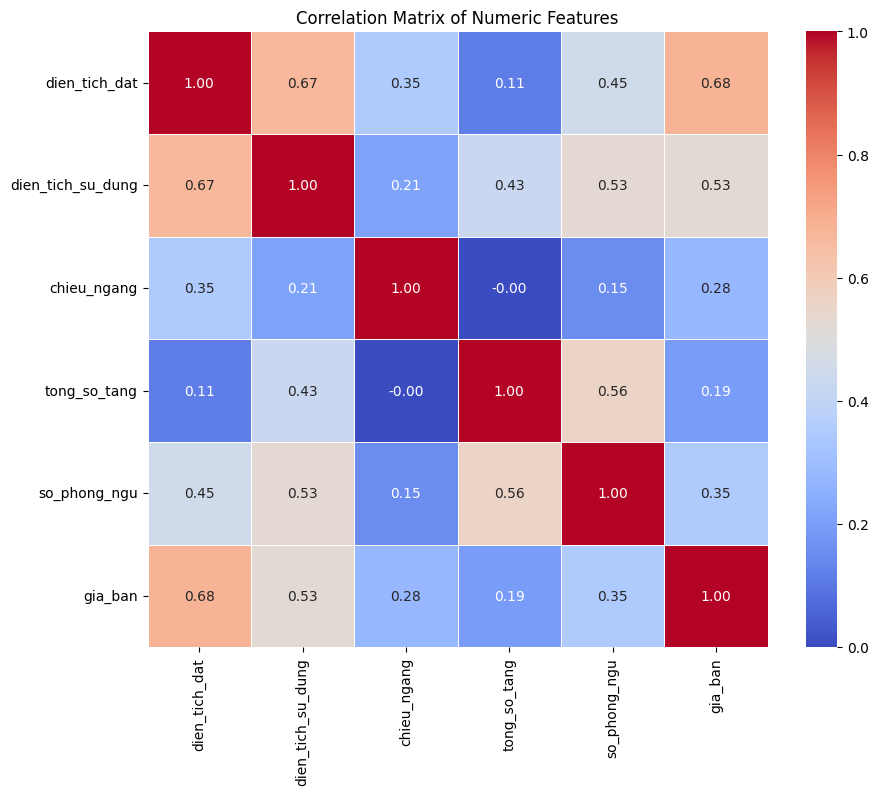

In [92]:
visualize_correlation(data)

**Xem hình dạng phân phối của dữ liệu**

In [93]:
def visualize_skewness_pandas(df):
    # Xác định danh sách cột và số lượng
    columns = [c for c, dtype in df.dtypes if dtype == 'double' or dtype == 'int']
    num_cols = len(columns)
    num_columns_grid = 3 # Số cột trong lưới biểu đồ (layout)
    num_rows_grid = math.ceil(num_cols / num_columns_grid) # Tự động tính số hàng cần thiết

    # Khởi tạo data
    pandas_data = df.select(columns).toPandas()

    # Cấu hình kích thước biểu đồ tổng thể
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(columns, start=1):
        plt.subplot(num_rows_grid, num_columns_grid, i)

        # Vẽ histogram kết hợp đường KDE (biểu thị mật độ phân phối)
        sns.histplot(pandas_data[column], kde=True)

        plt.title(f"Distribution of {column}", fontsize=12)
        plt.xlabel("") # Ẩn label trục X để biểu đồ thoáng hơn
        plt.ylabel("Frequency")

    # Tối ưu khoảng cách giữa các biểu đồ con
    plt.tight_layout()
    plt.show()

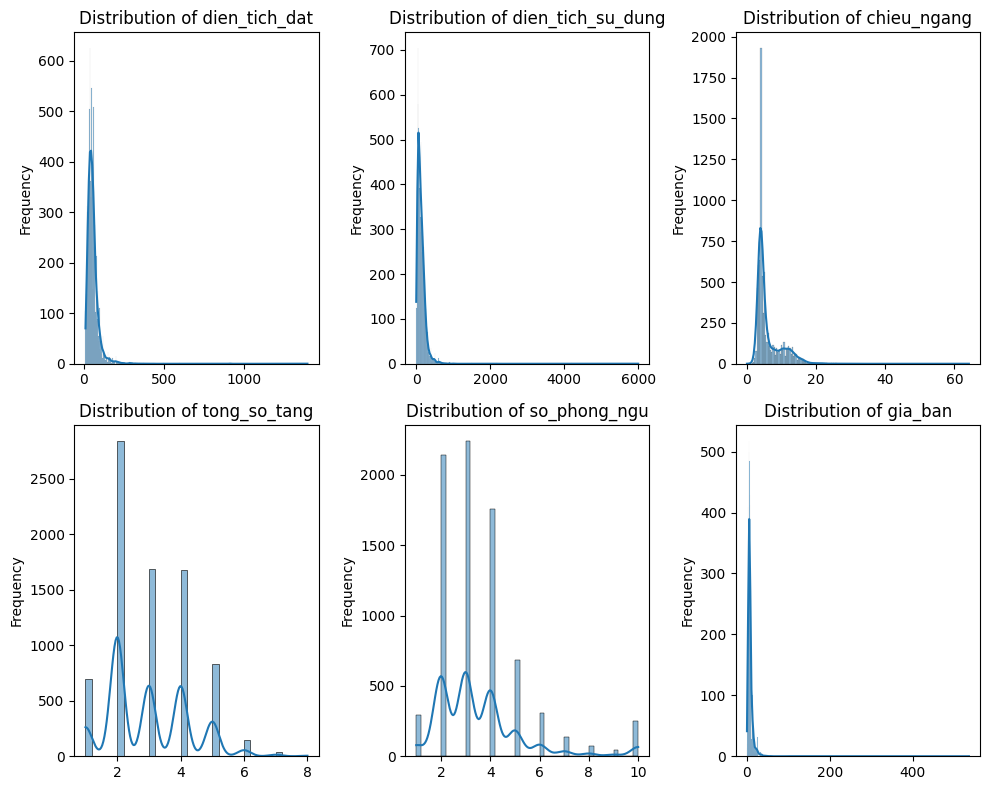

In [94]:
visualize_skewness_pandas(data)

**Kiểm tra outlier**

In [95]:
def visualize_outliers_pandas(df):

    # Xác định các cột số (numeric)
    numeric_cols = [c for c, dtype in df.dtypes if dtype == 'double' or dtype == 'int']

    pandas_data = df.select(numeric_cols).toPandas()

    # Tự động tính toán lưới biểu đồ (layout)
    num_plots = len(numeric_cols)
    num_cols_grid = 3 # Số cột biểu đồ mỗi hàng
    num_rows_grid = math.ceil(num_plots / num_cols_grid)
    plt.figure(figsize=(10, 8))
    for i, column in enumerate(numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)  # Adjust subplot grid as needed
        sns.boxplot(y=pandas_data[column])
        plt.title(f'Box Plot of {column}')
        plt.ylabel('') # Remove y-label as it's just the column name

    plt.tight_layout()
    plt.show()


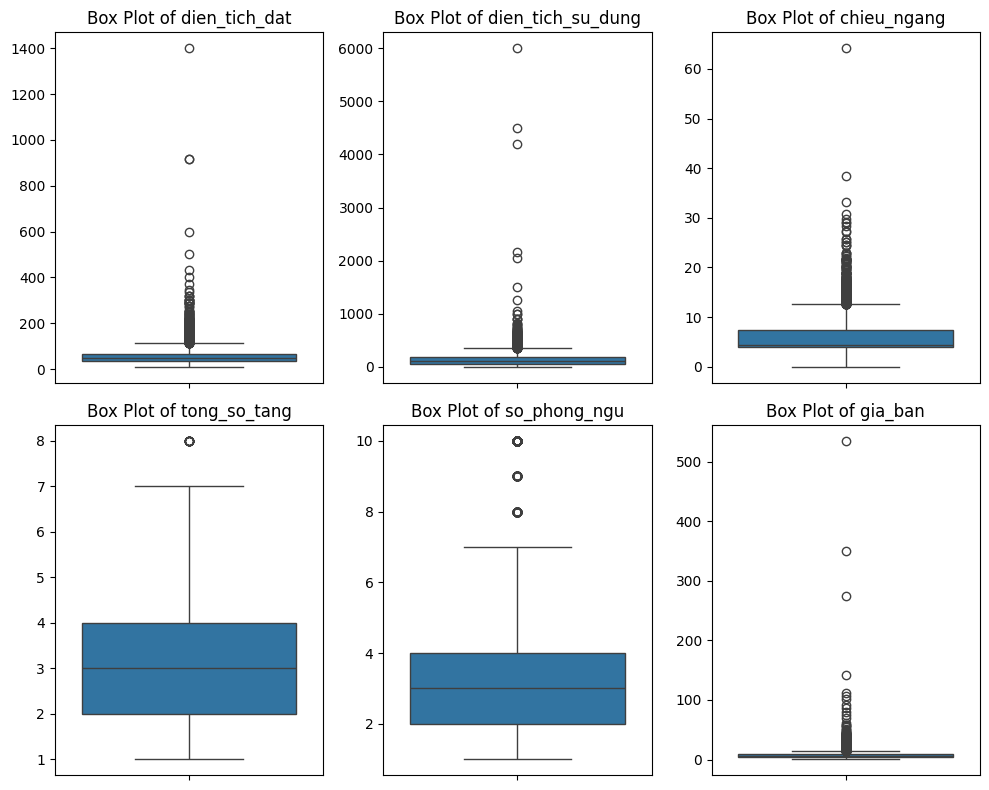

In [96]:
visualize_outliers_pandas(data)


**Xử lý outlier (Trimming)**

In [97]:
def trim_outliers(df, columns, lower_percentile, upper_percentile):
    """
    Xử lý outlier bằng phương pháp Trimming (Loại bỏ dòng).
    - columns: Danh sách các cột cần xử lý
    - lower_percentile: Ngưỡng dưới
    - upper_percentile: Ngưỡng trên
    """
    df_initial_count = df.count()

    for col_name in columns:
        # Tính toán giá trị tại các ngưỡng bách phân vị
        # Sử dụng độ chính xác cao hơn (0.0001) theo yêu cầu của bạn
        limits = df.stat.approxQuantile(col_name, [lower_percentile, upper_percentile], 0.0001)
        lower_limit = limits[0]
        upper_limit = limits[1]

        # Tính toán tỉ lệ dữ liệu sẽ bị loại bỏ
        # Lưu ý: Sử dụng F.col(col_name) để đảm bảo tính linh hoạt cho nhiều cột
        outlier_count = df.filter((F.col(col_name) < lower_limit) | (F.col(col_name) > upper_limit)).count()
        per_cent = (outlier_count / df_initial_count) * 100

        print(f"Cột {col_name}: Ngưỡng lọc [{lower_limit} - {upper_limit}]")
        print(f"Tỉ lệ loại bỏ: {per_cent:.4f}%")

        # Loại bỏ (Filter) các dòng vượt quá ngưỡng
        # Thay vì dùng F.when để gán giá trị, ta dùng filter để lọc bỏ dòng
        df = df.filter((F.col(col_name) >= lower_limit) & (F.col(col_name) <= upper_limit))

    print(f"Tổng số dòng sau khi lọc: {df.count()} (Giảm {df_initial_count - df.count()} dòng)")
    return df


In [98]:
# Áp dụng trim outlier
lower_percentile = 0.004
upper_percentile = 0.8
cols_to_fix = ["dien_tich_su_dung", "chieu_ngang", "gia_ban"]
data = trim_outliers(data, cols_to_fix, lower_percentile, upper_percentile)

Cột dien_tich_su_dung: Ngưỡng lọc [5.98173556894676 - 195.81467250752172]
Tỉ lệ loại bỏ: 20.2549%
Cột chieu_ngang: Ngưỡng lọc [2.1951219512195124 - 8.911327886790069]
Tỉ lệ loại bỏ: 16.0777%
Cột gia_ban: Ngưỡng lọc [1.5 - 7.9]
Tỉ lệ loại bỏ: 12.8849%
Tổng số dòng sau khi lọc: 4024 (Giảm 3900 dòng)


**Copy data cho project 2 (đã xử lý outlier, chưa xử lý skewness)**

In [99]:
data_pr2_2 = data

**Xử lý skew các biến numerical**

Hàm xử lý và trả kết quả về là data đã được xử lý skew giúp model học tốt hơn

In [100]:
def analyze_numerical_skewness(df, skew_threshold):
    """
    Phân tích skewness cho tất cả numerical variables
    """
    print("="*80)
    print("NUMERICAL VARIABLES SKEWNESS ANALYSIS")
    print("="*80)

    numerical_cols = [field.name for field in df.schema.fields
                       if isinstance(field.dataType, (IntegerType, DoubleType, FloatType, LongType))]
    results = {}

    for num_col in numerical_cols:
        try:
            # Tính các statistics quan trọng
            stats = df.agg(
                skewness(num_col).alias("skewness"),
                count(num_col).alias("count")
            ).collect()[0]

            skew_val = stats["skewness"]

            # Xác định mức độ skew
            if skew_val is None:
                skew_level = "N/A"
            elif np.abs(skew_val) <= 0.5:
                skew_level = "NORMAL (Nearly symmetric)"
            elif np.abs(skew_val) <= 1.0:
                skew_level = "MODERATE (Moderately skewed)"
            else:
                skew_level = "HIGH (Highly skewed)"

            # Lưu kết quả
            results[num_col] = {
                "skewness": skew_val,
                "skew_level": skew_level,
                "needs_transform": np.abs(skew_val) > skew_threshold if skew_val else False
            }

            # In kết quả
            print(f"\n📊 {num_col}:")
            print(f"   Skewness: {skew_val:.4f} ({skew_level})")
            print(f"   Needs Transform: {'✅ YES' if results[num_col]['needs_transform'] else '❌ NO'}")

        except Exception as e:
            print(f"Error analyzing {num_col}: {e}")
            results[num_col] = {"error": str(e)}

    return results

In [101]:
def transform_numerical_variables(df, transform_plan):
    """
    Transform numerical variables dựa trên skewness analysis
    """
    df_transformed = df
    best_lambda = 1 # default if normal distribution
    best_lambda_gia_ban = 1 # Initialize best_lambda_gia_ban here with a default value

    print("\n" + "="*80)
    print("APPLYING TRANSFORMATIONS")
    print("="*80)

    transformation_log = {}

    for col_name, method in transform_plan.items():
        if method == "none" or col_name not in df.columns:
            continue

        try:
            if method == "log":
                df_transformed = df_transformed.withColumn(f"{col_name}_log", log(col(col_name)))
                new_col = f"{col_name}_log"
                transformation_log[col_name] = {"method": "log", "new_col": new_col}
                print(f"✅ Applied LOG transform to {col_name} → {new_col}")

            elif method == "sqrt":
                df_transformed = df_transformed.withColumn(f"{col_name}_sqrt", sqrt(col(col_name)))
                new_col = f"{col_name}_sqrt"
                transformation_log[col_name] = {"method": "sqrt", "new_col": new_col}
                print(f"✅ Applied SQRT transform to {col_name} → {new_col}")

            elif method == "boxcox":
                sample_data = df_transformed.select(col_name).toPandas()[col_name]
                _, best_lambda = stats.boxcox(sample_data)
                if abs(best_lambda) < 1e-9:
                    # Khớp với giới hạn toán học của Box-Cox
                    df_transformed = df_transformed.withColumn(f"{col_name}_boxcox", F.log(F.col(col_name)))
                else:
                    df_transformed = df_transformed.withColumn(f"{col_name}_boxcox", (F.pow(F.col(col_name), best_lambda) - 1) / best_lambda)
                new_col = f"{col_name}_boxcox"
                if col_name == 'gia_ban': # Check if the current column is 'gia_ban'
                    best_lambda_gia_ban = best_lambda # Assign only if it's the target column

                transformation_log[col_name] = {"method": "boxcox", "new_col": new_col}
                print(f"✅ Applied BOX-COX (λ={best_lambda:.4f}) transform to {col_name} → {new_col}")

            # Kiểm tra skewness sau transform
            if new_col in df_transformed.columns:
                skew_after = df_transformed.select(skewness(new_col)).collect()[0][0]
                if skew_after is not None:
                    print(f"   Skewness after transform: {skew_after:.4f}")

            print(f"   Best_lambda: {best_lambda}")

        except Exception as e:
            print(f"❌ Error transforming {col_name} with {method}: {e}")
            transformation_log[col_name] = {"method": method, "error": str(e)}

    return df_transformed, best_lambda_gia_ban

In [102]:
def complete_skew_transform_pipeline(df, numerical_skew_threshold):

    # Phân tích
    skew_results = analyze_numerical_skewness(df, skew_threshold=numerical_skew_threshold)

    # Tạo transform plan cho numerical
    numerical_transform_plan = {}
    for col_name, stats in skew_results.items():
        if isinstance(stats, dict) and stats.get("needs_transform", False):
            skew_val = np.abs(stats["skewness"])

            if skew_val > 2.0:
                numerical_transform_plan[col_name] = "log"
            elif skew_val > 1.0:
                numerical_transform_plan[col_name] = "sqrt"
            elif skew_val > 0.5:
                numerical_transform_plan[col_name] = "boxcox"

    # Initialize df_processed and best_lambda_gia_ban before the conditional block
    df_processed = df
    best_lambda_gia_ban = 1

    # Áp dụng transform cho numerical
    if numerical_transform_plan:
        df_processed, best_lambda_gia_ban = transform_numerical_variables(df, transform_plan=numerical_transform_plan)
    else:
        print("No numerical transformations needed")

    # SUMMARY AND FINAL DATAFRAME
    print("\n" + "="*80)
    print("PIPELINE COMPLETION SUMMARY")
    print("="*80)

    # Tính số lượng columns mới
    original_cols_len = len(df.columns)
    new_cols_len = len(df_processed.columns)

    print(f"Original columns length: {original_cols_len}")
    print(f"New columns length after transformations: {new_cols_len}")
    print(f"Columns quantity added: {new_cols_len - original_cols_len}")


    return df_processed, best_lambda_gia_ban


In [103]:
# Sử dụng pipeline hoàn chỉnh
df_transformed, best_lambda_gia_ban = complete_skew_transform_pipeline(data, numerical_skew_threshold=0.5)
print(f"Kích thước dữ liệu sau transform: {df_transformed.count()} hàng, {len(df_transformed.columns)} cột")
print(f"Best_lambda_gia_ban: {best_lambda_gia_ban}")
# Xem kết quả
print("\nFirst few rows of transformed dataframe:")
df_transformed.show(5)

# Xem schema mới
print("\nNew schema:")
df_transformed.printSchema()

NUMERICAL VARIABLES SKEWNESS ANALYSIS

📊 dien_tich_dat:
   Skewness: 0.6679 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 dien_tich_su_dung:
   Skewness: 0.5334 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 chieu_ngang:
   Skewness: 1.6022 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 tong_so_tang:
   Skewness: 0.6505 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 so_phong_ngu:
   Skewness: 1.3146 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 gia_ban:
   Skewness: -0.2060 (NORMAL (Nearly symmetric))
   Needs Transform: ❌ NO

APPLYING TRANSFORMATIONS
✅ Applied BOX-COX (λ=0.3666) transform to dien_tich_dat → dien_tich_dat_boxcox
   Skewness after transform: -0.0190
   Best_lambda: 0.3665890842987722
✅ Applied BOX-COX (λ=0.4421) transform to dien_tich_su_dung → dien_tich_su_dung_boxcox
   Skewness after transform: -0.0661
   Best_lambda: 0.4420896194134531
✅ Applied SQRT transform to chieu_ngang → chieu_ngang_sqrt
   Skewness after tran

**Xem biểu đồ phân bố dữ liệu các cột sau khi đã xử lý skew**

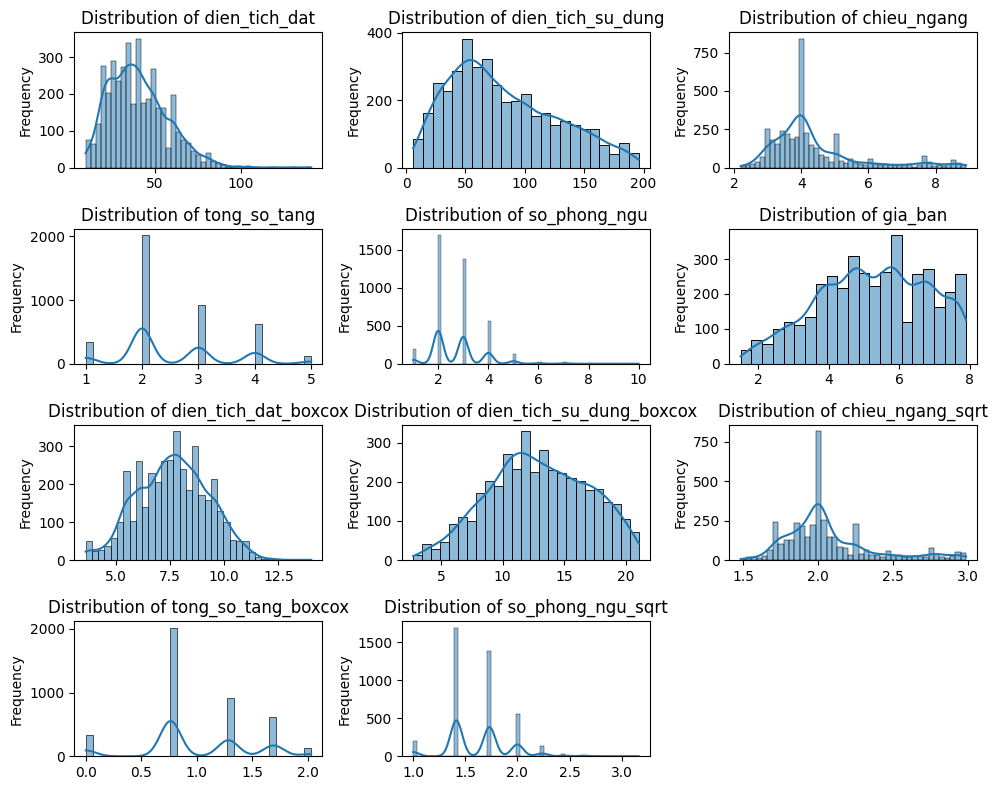

In [104]:
visualize_skewness_pandas(df_transformed)

**Kiểm tra outlier sau xử lý skew**

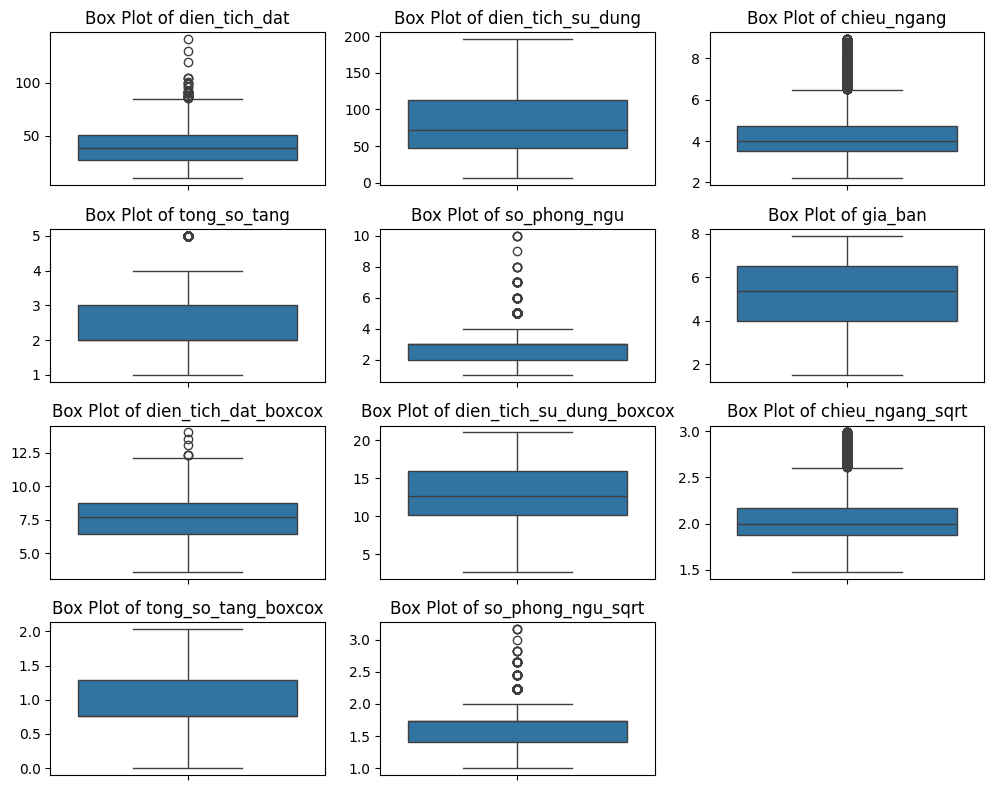

In [105]:
visualize_outliers_pandas(df_transformed)

**Copy data cho project 2 (đã xử lý outlier + skewness)**:

In [106]:
data_pr2_3 = df_transformed

**Xác định các cột cần lấy cho training**

In [107]:
def get_numerical_for_ml(df):

    # Lấy tất cả các cột số hiện có trong schema
    all_numerical_cols = [field.name for field in df.schema.fields
                        if isinstance(field.dataType, (IntegerType, DoubleType, FloatType, LongType))]

    # Xác định các cột đã được biến đổi (_log, _sqrt, _boxcox)
    # Pattern này tách tên gốc và hậu tố
    pattern = r"^(.*)(_log|_sqrt|_boxcox)$"
    transformed_map = {}

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        if match:
            root_name = match.group(1)
            transformed_map[root_name] = col

    # Logic ưu tiên tên cột đã biến đổi nhưng loại bỏ bất kỳ tên cột có liên quan gia_ban
    numerical_cols_for_ml = []
    seen_roots = set()

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        root = match.group(1) if match else col

        # Kiểm tra nếu root chứa "gia_ban" thì bỏ qua hoàn toàn
        if "gia_ban" in root:
            continue

        if root not in seen_roots:
            # Nếu gốc này có bản biến đổi, lấy bản biến đổi
            if root in transformed_map:
                numerical_cols_for_ml.append(transformed_map[root])
            else:
                # Nếu không có bản biến đổi, lấy cột gốc
                numerical_cols_for_ml.append(root)
            seen_roots.add(root)

    return numerical_cols_for_ml


In [108]:
numerical_cols = get_numerical_for_ml(df_transformed)
exclude_cols = {'tieu_de', 'mo_ta'}
categorical_cols = [field.name for field in df_transformed.schema.fields
                       if isinstance(field.dataType, (StringType)) and field.name not in exclude_cols]

In [109]:
categorical_cols

['loai_hinh',
 'giay_to_phap_ly',
 'tinh_trang_noi_that',
 'huong_cua_chinh',
 'dac_diem',
 'dia_chi_cu',
 'dia_chi_moi']

**Chuẩn hóa các đặc trưng**
- Áp dụng Robust Scaler cho các biến numerical
- Áp dụng StringIndexer + OneHot Encoder cho các biến categorical


In [110]:
# Standard scale cho biến numerical
assembler = VectorAssembler(inputCols=numerical_cols, outputCol="features_to_scale")

scaler = RobustScaler(inputCol="features_to_scale", outputCol="scaled_features",
                      withScaling=True, withCentering=True,
                      lower=0.25, upper=0.75)

In [111]:
indexed_cols = [col + '_index' for col in categorical_cols]
oh_encoded_cols = [col + '_vec' for col in categorical_cols]
indexer = []
encoder = []

# Đối với biến categorical
# apply StringIndexer
for i, col_name in enumerate(categorical_cols):
    indexer.append(StringIndexer(inputCol=col_name, outputCol=indexed_cols[i], handleInvalid='keep'))

# apply OneHotEncoder
for i, col_name in enumerate(indexed_cols):
    encoder.append(OneHotEncoder(inputCol=col_name, outputCol=oh_encoded_cols[i]))

# Final vector
# feature_cols = ['scaled_features', 'loai_hinh_vec', 'giay_to_phap_ly_vec', 'tinh_trang_noi_that_vec', 'huong_cua_chinh_vec', 'dac_diem_vec', 'dia_chi_cu_vec', 'dia_chi_moi_vec']
feature_cols = [scaler.getOutputCol(), *[f"{col}_vec" for col in categorical_cols]]
assembler_final = VectorAssembler(inputCols=feature_cols, outputCol="final_features")

**Train/ Test Split**



In [112]:
df_train, df_test = df_transformed.randomSplit([0.8, 0.2], seed=42)

print(f"Training data count: {df_train.count()}")
print(f"Testing data count: {df_test.count()}")


Training data count: 3254
Testing data count: 770


**Model pipeline**

In [113]:
def build_and_evaluate_models(train_data, test_data, param_grid=False, \
                              transformed_target_col=""):
    # Create an instance of models
    lr = LinearRegression(featuresCol='final_features', labelCol=transformed_target_col)
    rf = RandomForestRegressor(featuresCol='final_features', labelCol=transformed_target_col, seed=42,
                               numTrees=40, # n_estimators
                               maxDepth=30,
                               minInfoGain=0.0,
                               minInstancesPerNode=1, # min_samples_leaf
                               featureSubsetStrategy="0.2", # max_features
                               )
    xgb = SparkXGBRegressor(features_col='final_features', label_col=transformed_target_col, num_workers=CPUcores_num, seed=42,
                            n_estimators=100,
                            learning_rate=0.1,
                            )
    lgbm = LightGBMRegressor(featuresCol='final_features', labelCol=transformed_target_col, objective="regression", seed=42,
                             numIterations=100,     # n_estimators
                             maxDepth=5,            # max_depth
                             learningRate=0.1,      # learning_rate
                             )
    gbt = GBTRegressor(featuresCol='final_features', labelCol=transformed_target_col, seed=42,
                       maxIter=100, # n_estimators
                       stepSize=0.1, # learning_rate
                       maxDepth=5    # Mặc định của Spark là 5 (Sklearn mặc định là 3)
                       )

    # Define the hyperparameter grid
    param_grid_lr = (
        ParamGridBuilder()
        .addGrid(lr.regParam, [0.01, 0.1, 1.0])
        .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
        .addGrid(lr.maxIter, [10, 100])
        .build()
    )

    param_grid_rf = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50, 100])
        .addGrid(rf.maxDepth, [5, 10])
        .addGrid(rf.subsamplingRate, [0.8, 1.0])
        .build()
    )

    param_grid_xgb = (
        ParamGridBuilder()
        .addGrid(xgb.max_depth, [4, 6])
        .addGrid(xgb.learning_rate, [0.01, 0.1])
        .addGrid(xgb.n_estimators, [50, 100])
        .build()
    )

    param_grid_lgbm = (
        ParamGridBuilder()
        .addGrid(lgbm.learningRate, [0.01, 0.1])
        .addGrid(lgbm.numLeaves, [31, 60])
        .addGrid(lgbm.numIterations, [100, 200])
        .build()
    )

    param_grid_gbt = (
        ParamGridBuilder()
        .addGrid(gbt.maxDepth, [5, 10])
        .addGrid(gbt.maxIter, [20, 30])
        .addGrid(gbt.stepSize, [0.01, 0.1])
        .build()
    )

    # Instantiate RegressionEvaluator
    reg_evaluator = RegressionEvaluator(metricName="rmse", labelCol=transformed_target_col, predictionCol="prediction")

    models = [lr, rf, xgb, lgbm, gbt]
    model_names = ["Linear Regression", "Random Forest Regressor", "XGBoost", "LightGBM Regressor", "Gradient-Boosted Trees Regressor"]
    param_grids = [param_grid_lr, param_grid_rf, param_grid_gbt, param_grid_lgbm, param_grid_xgb]
    simple_selected_models = []
    best_selected_models = []
    param_dicts = []
    pineline_models = []
    predictions_df = []

    # Initialize evaluator
    evaluator_rmse = RegressionEvaluator(metricName="rmse", labelCol="gia_ban", predictionCol="final_prediction")
    evaluator_mae = RegressionEvaluator(metricName="mae", labelCol="gia_ban", predictionCol="final_prediction")
    evaluator_r2 = RegressionEvaluator(metricName="r2", labelCol="gia_ban", predictionCol="final_prediction")

    results = {}

    for i in range(len(models)):
        cv = CrossValidator(
                estimator=models[i],
                estimatorParamMaps=param_grids[i],
                evaluator=reg_evaluator,
                numFolds=5,
                parallelism=CPUcores_num,  # Adjust based on runtime system's capabilities
                seed=42
            )

        # Train
        if param_grid:
            pineline = Pipeline(stages=[assembler, scaler, *indexer, *encoder, assembler_final, cv])
            pineline_model = pineline.fit(train_data)
            pineline_models.append(pineline_model)
            cv_model = pineline_model.stages[-1]
            model = cv_model.bestModel
            best_selected_models.append(model)
            param_dicts.append(model.extractParamMap())

        else:
            pineline = Pipeline(stages=[assembler, scaler, *indexer, *encoder, assembler_final, models[i]])
            pineline_model = pineline.fit(train_data)
            pineline_models.append(pineline_model)
            model = pineline_model.stages[-1]
            simple_selected_models.append(model)

        # Predict
        predictions = pineline_model.transform(test_data)

         # Convert back to original scale
        if transformed_target_col == "gia_ban_sqrt":
            predictions = predictions.withColumn("final_prediction", col("prediction") ** 2)
        elif transformed_target_col == "gia_ban_log":
            predictions = predictions.withColumn("final_prediction", exp(col("prediction")))
        elif transformed_target_col == "gia_ban_boxcox":
            predictions = predictions.withColumn("final_prediction", F.pow(F.col("prediction") * best_lambda_gia_ban + 1, 1/best_lambda_gia_ban))
        elif transformed_target_col == "gia_ban":
            predictions = predictions.withColumn("final_prediction", col("prediction"))
        predictions_df.append(predictions)

        # Evaluate
        rmse_value = evaluator_rmse.evaluate(predictions)
        mae_value = evaluator_mae.evaluate(predictions)
        r2_value = evaluator_r2.evaluate(predictions)

        results[model_names[i]] = {
            "R2": builtins.round(r2_value, 3),
            "MAE": builtins.round(mae_value, 3),
            "RMSE": builtins.round(rmse_value, 3)
        }

        # Print metrics
        print(f"Metrics for model {model_names[i]}:")
        print(f"  RMSE: {rmse_value:.3f}")
        print(f"  MAE: {mae_value:.3f}")
        print(f"  R-squared: {r2_value:.3f}")

        # Visuallize
        pandas_predictions = predictions.select('gia_ban', 'final_prediction').toPandas()

        plt.figure(figsize=(10, 8))
        sns.scatterplot(x='gia_ban', y='final_prediction', data=pandas_predictions, alpha=0.6)

        # Add a diagonal line for ideal prediction
        min_val = min(pandas_predictions['gia_ban'].min(), pandas_predictions['final_prediction'].min())
        max_val = max(pandas_predictions['gia_ban'].max(), pandas_predictions['final_prediction'].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

        plt.xlabel('Actual Price')
        plt.ylabel('Predicted Price')
        plt.title(f'Actual vs. Predicted Prices of model {model_names[i]})')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    # Xuất kết quả so sánh
    print("\nBảng so sánh kết quả:")
    print(pd.DataFrame(results).T)

    if param_grid:
        return best_selected_models, param_dicts, pineline_models, model_names, predictions_df
    else:
        return simple_selected_models, pineline_models, model_names, predictions_df

**Bên dưới là kết quả trả về sau khi áp dụng Pipeline để fit/transform dữ liệu (không tunning thêm tham số)**

Metrics for model Linear Regression:
  RMSE: 0.858
  MAE: 0.674
  R-squared: 0.695


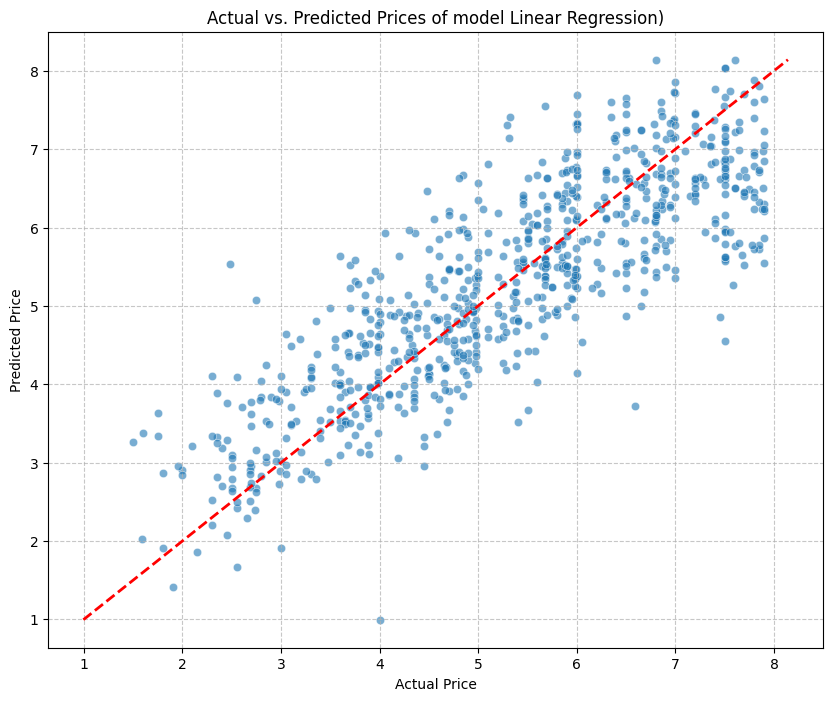

Metrics for model Random Forest Regressor:
  RMSE: 0.755
  MAE: 0.574
  R-squared: 0.762


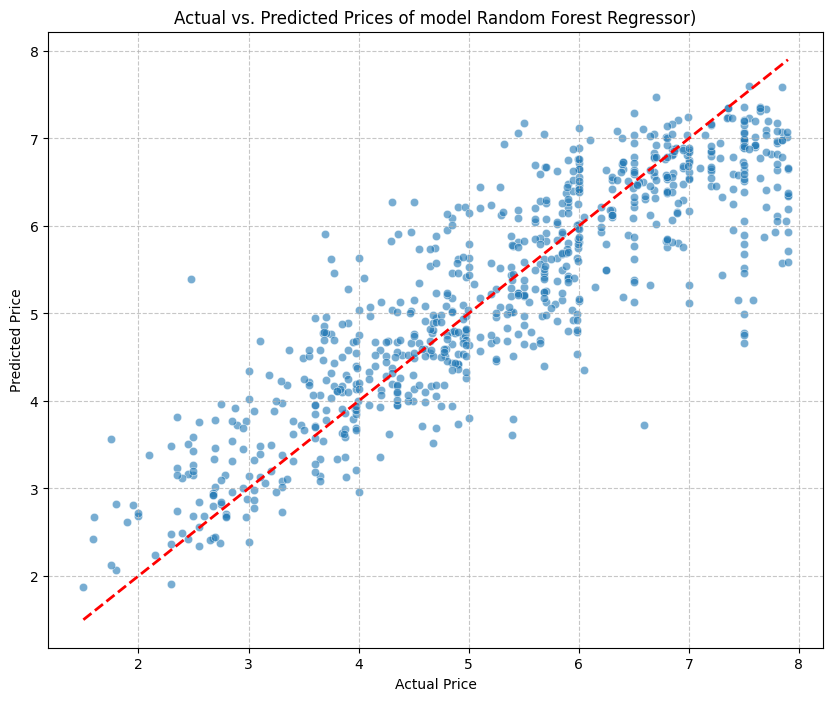

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 8 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'learning_rate': 0.1, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


Metrics for model XGBoost:
  RMSE: 0.733
  MAE: 0.554
  R-squared: 0.776


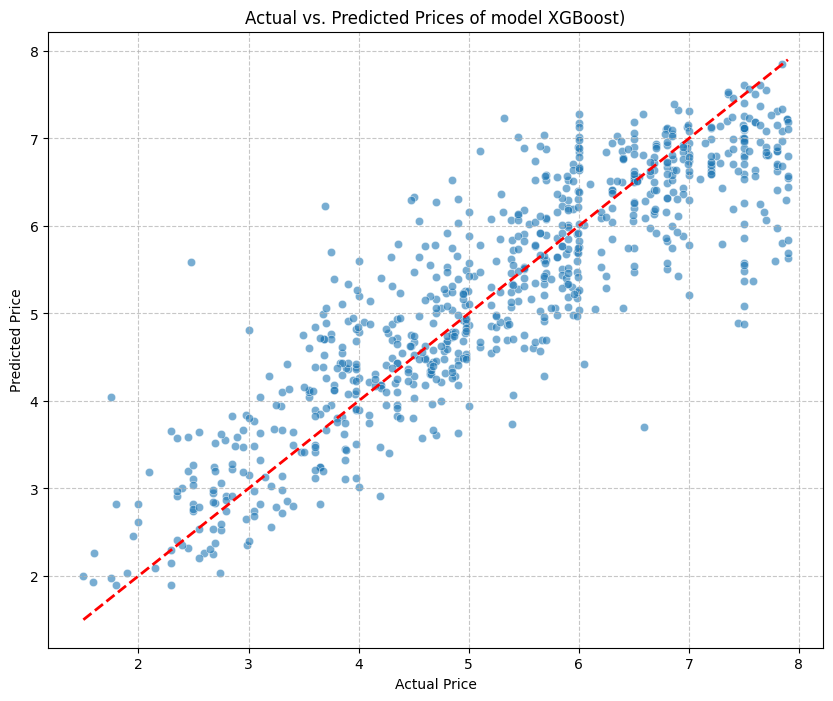

Metrics for model LightGBM Regressor:
  RMSE: 0.754
  MAE: 0.569
  R-squared: 0.765


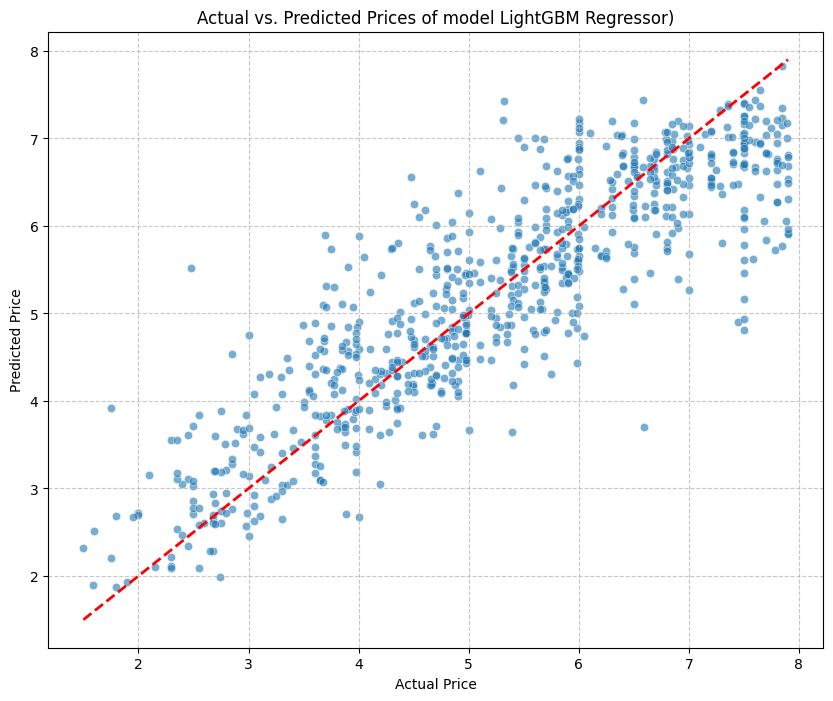

Metrics for model Gradient-Boosted Trees Regressor:
  RMSE: 0.779
  MAE: 0.592
  R-squared: 0.748


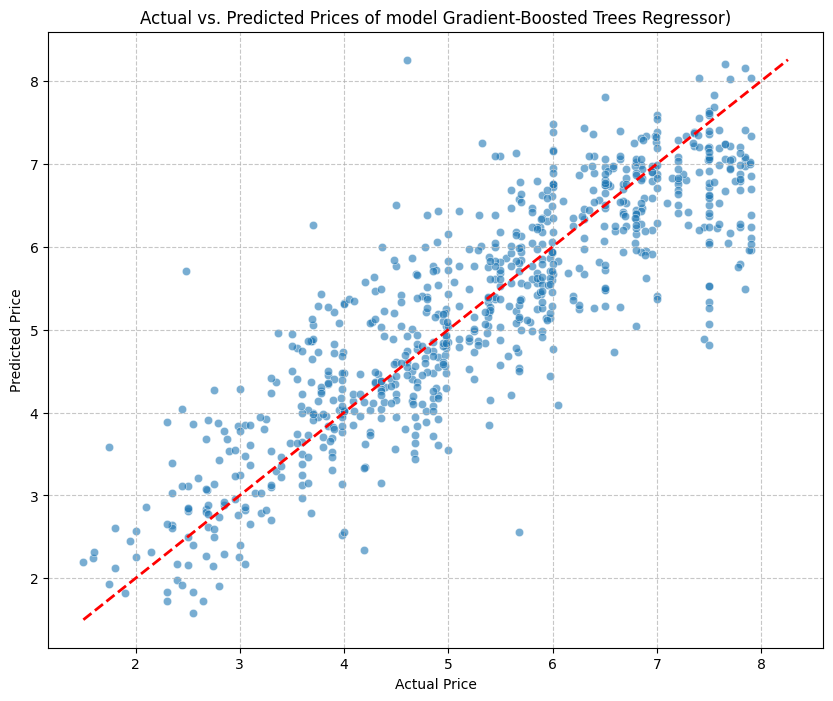


Bảng so sánh kết quả:
                                     R2    MAE   RMSE
Linear Regression                 0.695  0.674  0.858
Random Forest Regressor           0.762  0.574  0.755
XGBoost                           0.776  0.554  0.733
LightGBM Regressor                0.765  0.569  0.754
Gradient-Boosted Trees Regressor  0.748  0.592  0.779


In [114]:
transformed_target_cols = [col for col in df_transformed.columns if 'gia_ban_' in col]
if transformed_target_cols:
    tf_target_col = transformed_target_cols[0]
else:
    tf_target_col = 'gia_ban'
simple_sl_models, pl_models, md_names, predictions_df = build_and_evaluate_models(df_train, df_test, param_grid=False, \
                                                        transformed_target_col=tf_target_col)

**Xem predict top 10 từ XGBoost**

In [115]:
predictions_df[2].select(data.columns + ['final_prediction']).show(10)

+--------------------+--------------------+-------------+-----------------+------------------+------------+------------+--------------------+---------------+-------------------+---------------+---------------+--------------------+--------------------+-------+------------------+
|             tieu_de|               mo_ta|dien_tich_dat|dien_tich_su_dung|       chieu_ngang|tong_so_tang|so_phong_ngu|           loai_hinh|giay_to_phap_ly|tinh_trang_noi_that|huong_cua_chinh|       dac_diem|          dia_chi_cu|         dia_chi_moi|gia_ban|  final_prediction|
+--------------------+--------------------+-------------+-----------------+------------------+------------+------------+--------------------+---------------+-------------------+---------------+---------------+--------------------+--------------------+-------+------------------+
|(12-GV) 6 ,05 tỉ ...|✅ Diện tích: 34m2...|         34.0|             34.0| 3.090909090909091|           2|         2.0|nha_mat_pho_mat_tien|       da_co_so|  hoan


**Nhận xét:**\
**XGBoost là model tốt nhất so với các model còn lại (xét theo RMSE, MAE thấp nhất, R-squared cao nhất)**

## **Bài toán số 2**

**Sử dụng data đã predict của tập test với model XGBoost**

In [116]:
pred_df = predictions_df[2].select(data.columns + ['final_prediction'])
df = pred_df.withColumn("quan_huyen", F.regexp_extract(F.col("dia_chi_cu"), r"((quan|huyen)_.*)", 1))
df = df.withColumn("quan_huyen_loai_hinh",
                   F.concat_ws("_", F.col("quan_huyen"), F.col("loai_hinh")))

In [117]:
def visualize_bar_price(df, groupby_features):
    # Tính toán giá trung bình theo loại hình trong Spark
    stats_df = df.groupBy(groupby_features).agg(
        F.mean("gia_ban").alias("Thực tế"),
        F.mean("final_prediction").alias("Dự đoán")
    ).toPandas().sort_values(by="Thực tế")

    # Chuyển sang dạng long-format để vẽ cột đôi
    stats_melted = stats_df.melt(id_vars=groupby_features, var_name="Type", value_name="Average_Price")

    # Vẽ biểu đồ kết hợp ---
    fig, ax1 = plt.subplots(figsize=(8, 6))
    sns.set_style("whitegrid")

    # Vẽ Biểu đồ cột (Bar Chart)
    groupby_features_merging_1 = "_".join(groupby_features)
    groupby_features_merging_2 = " - ".join([f.replace("_", " ").capitalize() for f in groupby_features])
    sns.barplot(data=stats_melted, x=groupby_features_merging_1, y="Average_Price", hue="Type", ax=ax1, palette="muted", alpha=0.8)
    ax1.set_ylabel("Giá trung bình (Tỷ VNĐ)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("")
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.subplots_adjust(bottom=0.25) # Tăng số này nếu tên quá dài
    plt.title(f"Mặt bằng giá theo: {groupby_features_merging_2}", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

**Theo loại hình**

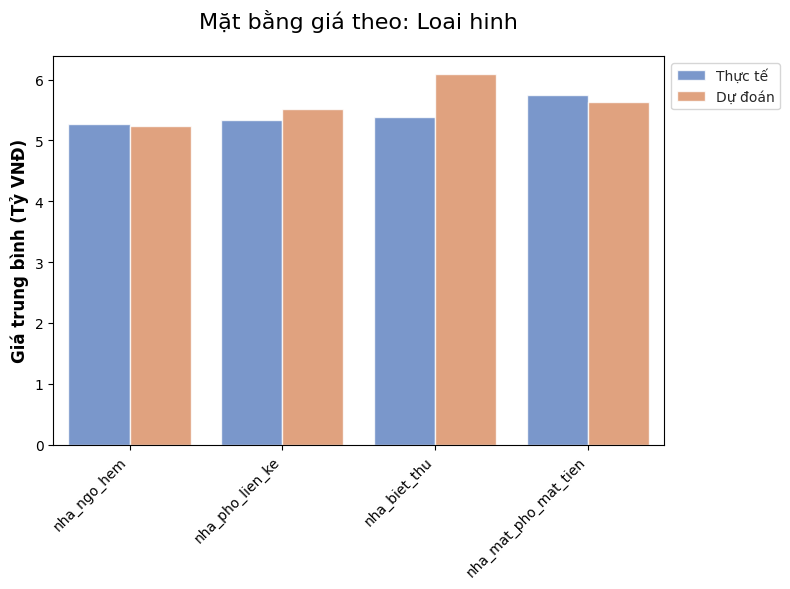

In [118]:
df_histplot_1 = df
groupby_features = ["loai_hinh"]
visualize_bar_price(df_histplot_1, groupby_features)

**Theo quận huyện**

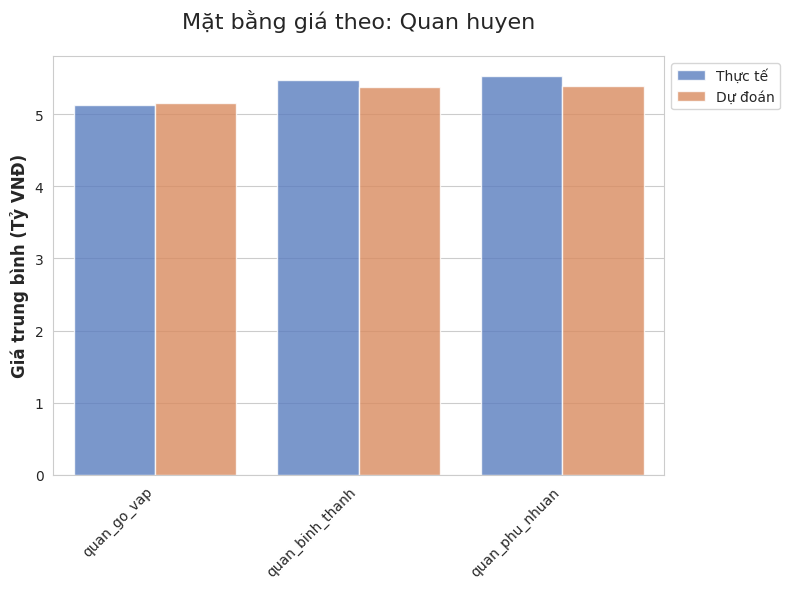

In [119]:
groupby_features = ["quan_huyen"]
visualize_bar_price(df_histplot_1, groupby_features)

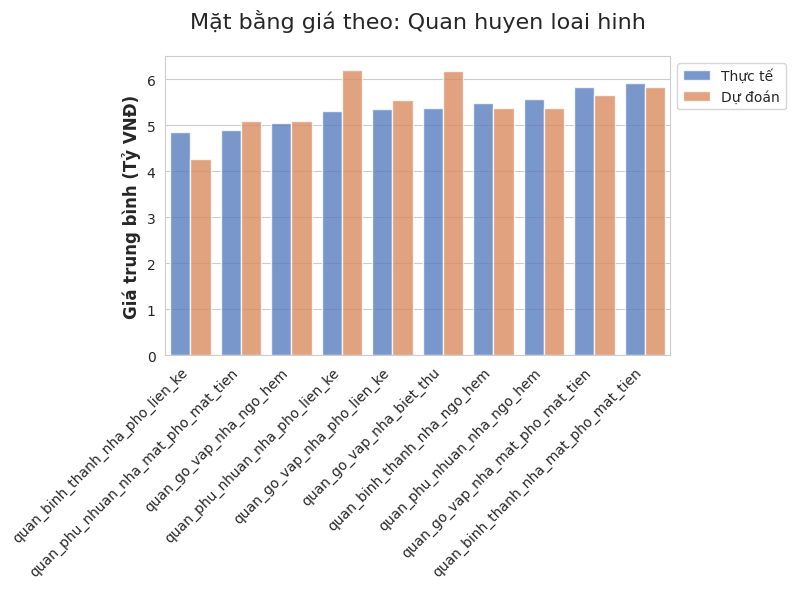

In [120]:
groupby_features = ["quan_huyen_loai_hinh"]
visualize_bar_price(df_histplot_1, groupby_features)

**Theo tổng số tầng**

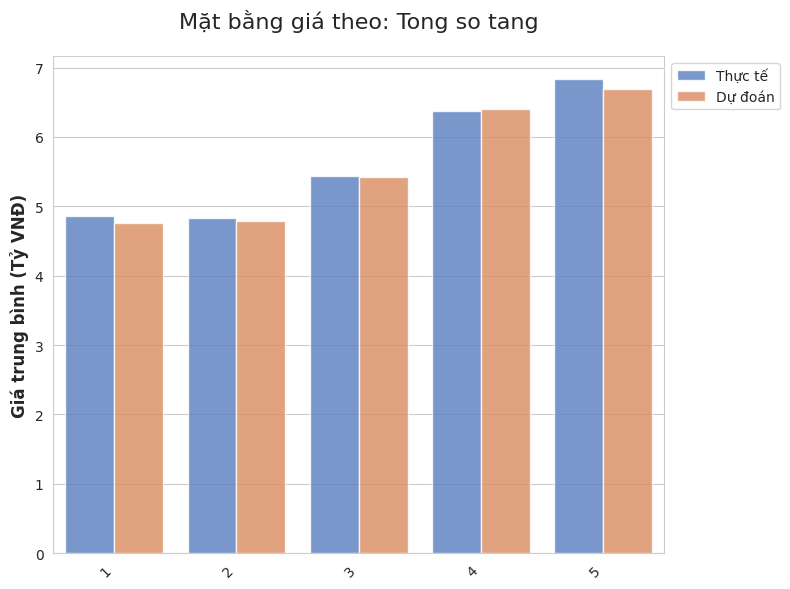

In [121]:
groupby_features = ["tong_so_tang"]
visualize_bar_price(df_histplot_1, groupby_features)

### Phương Pháp 1: Residual-Z

### Ý tưởng
Dùng XGBoost dự đoán giá → tính **sai số** giữa giá thực và giá dự đoán → chuẩn hóa thành Z-score.  
Căn nhà có **|Z| lớn** nghĩa là giá thực lệch xa so với mức mà thị trường "kỳ vọng" → bất thường.

### Công thức
$$e = y_{\text{thực tế}} - y_{\text{dự đoán}}$$
$$Z_{resid} = \frac{e - \bar{e}}{\sigma_e}$$
$$S_{resid} = \frac{|Z| - |Z|_{min}}{|Z|_{max} - |Z|_{min}} \quad \text{(clip tại |Z|=3)}$$

- Z > 0 → giá thực **cao hơn** dự đoán (có thể quá đắt)  
- Z < 0 → giá thực **thấp hơn** dự đoán (có thể quá rẻ)  
- |Z| > 2 → bất thường | |Z| > 3 → rất bất thường

#### **Khai báo hàm**

In [122]:
def dectect_real_estate_anomalies_by_residual_z(df, groupby_features):
    df = df.withColumn("residual", F.col("gia_ban") - F.col("final_prediction"))
    window_spec = Window.partitionBy(groupby_features)
    df = df.withColumn("avg_res", F.avg("residual").over(window_spec))
    df = df.withColumn("std_res", F.stddev("residual").over(window_spec))
    df = df.withColumn("residual_z", (F.col("residual") - F.col("avg_res")) / (F.col("std_res")))
    df = df.withColumn("violate_residual_z", F.when(F.abs(F.col("residual_z")) > 3, 1).otherwise(0))
    return df

In [123]:
def composite_scores(df, groupby_features, methods, threshold_pr_min=None, threshold_pr_max=None, threshold_po_min=None, threshold_po_max=None, feature_cols=None, isf_contamination=None):
    # Initialize df_anomalies with the input df
    df_anomalies = df

    for method in methods:
        match method:
            case "residual_z":
                df_anomalies = dectect_real_estate_anomalies_by_residual_z(df_anomalies, groupby_features)
            case "min_max":
                df_anomalies = dectect_real_estate_anomalies_by_min_max(df_anomalies, groupby_features, threshold_pr_min, threshold_pr_max)
            case "outside_conf":
                df_anomalies = dectect_real_estate_anomalies_by_outside_conf(df_anomalies, groupby_features, threshold_po_min, threshold_po_max)
            case "isolation_forest":
                df_anomalies = dectect_real_estate_anomalies_by_isolation_forest(df_anomalies, groupby_features, feature_cols, isf_contamination)

    # Điểm tổng hợp: Score 0–100
    df_anomalies = df_anomalies.withColumn("raw_anomaly_score", lit(0))
    for method, weights in methods.items():
        for col_name, weight in weights.items():
            df_anomalies = df_anomalies.withColumn("raw_anomaly_score", F.col("raw_anomaly_score") + F.col(col_name) * weight)

    # Chuẩn hóa về thang 100
    max_val = df_anomalies.select(F.max("raw_anomaly_score")).collect()[0][0]
    if max_val == 0:
        df_anomalies = df_anomalies.withColumn("final_anomaly_score", F.lit(0.0))
    else:
        df_anomalies = df_anomalies.withColumn("final_anomaly_score", (F.col("raw_anomaly_score") / max_val) * 100)

    return df_anomalies

In [124]:
def extract_anomalies(df, threshold_outlier_percent):
    df_anomalies = df
    ceiling_score = df_anomalies.stat.approxQuantile("final_anomaly_score", [1-threshold_outlier_percent], 0.0)[0]
    list_anomalies = df_anomalies.filter(F.col("final_anomaly_score") >= ceiling_score) \
                                .select(df_anomalies.columns).orderBy(F.desc("final_anomaly_score"))
    return list_anomalies

In [125]:
def report_anomalies(df, groupby_features, methods, methods_features, methods_flags, threshold_outlier_percent, threshold_pr_min=None, threshold_pr_max=None, threshold_po_min=None, threshold_po_max=None, feature_cols=None, isf_contamination=None):
    df_anomalies = composite_scores(df, groupby_features, methods, threshold_pr_min, threshold_pr_max, threshold_po_min, threshold_po_max, feature_cols, isf_contamination)
    list_anomalies = extract_anomalies(df_anomalies, threshold_outlier_percent)
    orderby_feartures = ["final_anomaly_score"] + groupby_features + methods_features
    combined_condition = reduce(lambda a, b: a | b, [F.col(c) == 1 for c in methods_flags])
    list_anomalies = list_anomalies.where(combined_condition) \
                                .select("gia_ban", "final_prediction", *methods_features if methods_features else [], *methods_flags, "final_anomaly_score", \
                                        *groupby_features, "dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "tong_so_tang", \
                                        "so_phong_ngu", "giay_to_phap_ly", "tinh_trang_noi_that", "dac_diem", "dia_chi_cu", "dia_chi_moi") \
                                .orderBy([F.desc(c) for c in orderby_feartures]) # Sắp xếp theo tất cả các cột nhóm

    # Hiển thị data
    print(f"Số lượng nhà bất thường phát hiện: {list_anomalies.count()}")
    list_anomalies.show(truncate=False)

    return df_anomalies, list_anomalies

**Biểu đồ Scatter: Giá thực tế vs Giá dự đoán (Highlight Outliers)**

Biểu đồ này giúp ta thấy rõ những căn nhà có sai số cực lớn (nằm xa đường chéo)

In [126]:
def scatter_hightlight_outliers(df_anomalies, list_anomalies):
    # Chuyển kết quả top bất thường và một phần dữ liệu mẫu sang Pandas
    pdf_sample = df_anomalies.sample(False, 0.1).toPandas() # Lấy 10% dữ liệu để vẽ nền
    pdf_anomalies = list_anomalies.toPandas()

    plt.figure(figsize=(12, 8))

    # Vẽ dữ liệu bình thường
    sns.scatterplot(data=pdf_sample, x='final_prediction', y='gia_ban', alpha=0.3, label='Normal Data', color='gray')

    # Highlight dữ liệu bất thường
    sns.scatterplot(data=pdf_anomalies, x='final_prediction', y='gia_ban', color='red', label='Anomalies', s=100, edgecolor='black')

    # Đường chéo lý tưởng
    max_val = max(pdf_sample['gia_ban'].max(), pdf_sample['final_prediction'].max())
    plt.plot([0, max_val], [0, max_val], '--', color='blue', alpha=0.5)

    plt.title("Phát hiện bất thường: Giá thực tế vs Giá dự đoán")
    plt.xlabel("Giá dự đoán (Model Prediction)")
    plt.ylabel("Giá thực tế (Actual Price)")
    plt.legend()
    plt.show()

In [127]:
def visualize_anomalies_by_selected_features(df, methods_flags):
    # Chỉ lấy các cột cần thiết và chuyển về Pandas để nhẹ bộ nhớ
    # Giả sử is_anomaly_iforest: 1 là bất thường (đỏ), 0 là bình thường (xanh)
    pdf = df.select(
        "quan_huyen_loai_hinh",
        "giay_to_phap_ly",
        "gia_ban",
        *methods_flags
    ).toPandas()

    # Khởi tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Biểu đồ phân cụm các điểm bất thường', fontsize=13, fontweight='bold')

    # Định nghĩa bảng màu
    # 1 (Bất thường) -> Đỏ
    # 0 (Bình thường) -> Xanh

    pdf['is_any_anomaly'] = pdf[methods_flags].max(axis=1)
    pdf_sorted = pdf.sort_values(by='is_any_anomaly', ascending=True)
    combined_colors = pdf_sorted['is_any_anomaly'].map({1: '#D32F2F', 0: '#4CAF50'})
    point_sizes = pdf_sorted['is_any_anomaly'].map({1: 30, 0: 15})
    # Biểu đồ 1: Quận/ huyện - Loại hình vs Giá
    axes[0].scatter(
        pdf['quan_huyen_loai_hinh'],
        pdf['gia_ban'],
        c=combined_colors,
        s=point_sizes,
        alpha=0.5
    )
    axes[0].set_title('Quận huyện & loại hình vs Giá\n(đỏ = bất thường)')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Giá bán')
    axes[0].tick_params(axis='x', rotation=45)
    for label in axes[0].get_xticklabels():
        label.set_horizontalalignment('right')

    # Biểu đồ 2: Diện tích vs Giá
    axes[1].scatter(
        pdf['giay_to_phap_ly'],
        pdf['gia_ban'],
        c=combined_colors,
        s=point_sizes,
        alpha=0.5
    )
    axes[1].set_title('Tình trạng pháp lý vs Giá\n(đỏ = bất thường)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Giá bán')
    axes[1].tick_params(axis='x', rotation=45)
    for label in axes[1].get_xticklabels():
        label.set_horizontalalignment('right')

    plt.tight_layout()
    plt.show()


#### **Thực thi Residual-z**

### Residual-z chuẩn hóa sai số theo 'loai_hinh' vì mức độ biến động giá khác nhau rõ rệt giữa các loại hình

In [128]:
threshold_outlier_percent = 0.05  # 5%
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "residual_z": {
        "violate_residual_z": 100 # Trọng số cho điểm số tổng hợp
    }
}
methods_features = ["residual"]
methods_flags = ["violate_residual_z"]

df_anomalies, list_anomalies = report_anomalies(df, groupby_features, methods, methods_features, methods_flags, threshold_outlier_percent)


Số lượng nhà bất thường phát hiện: 6
+-------+------------------+-------------------+------------------+-------------------+---------------+-----------+-------------+------------------+------------------+------------+------------+---------------+-------------------+---------------+-------------------------+------------------+
|gia_ban|final_prediction  |residual           |violate_residual_z|final_anomaly_score|quan_huyen     |loai_hinh  |dien_tich_dat|dien_tich_su_dung |chieu_ngang       |tong_so_tang|so_phong_ngu|giay_to_phap_ly|tinh_trang_noi_that|dac_diem       |dia_chi_cu               |dia_chi_moi       |
+-------+------------------+-------------------+------------------+-------------------+---------------+-----------+-------------+------------------+------------------+------------+------------+---------------+-------------------+---------------+-------------------------+------------------+
|6.59   |3.730440616607666 |2.859559383392334  |1                 |100.0              |qua

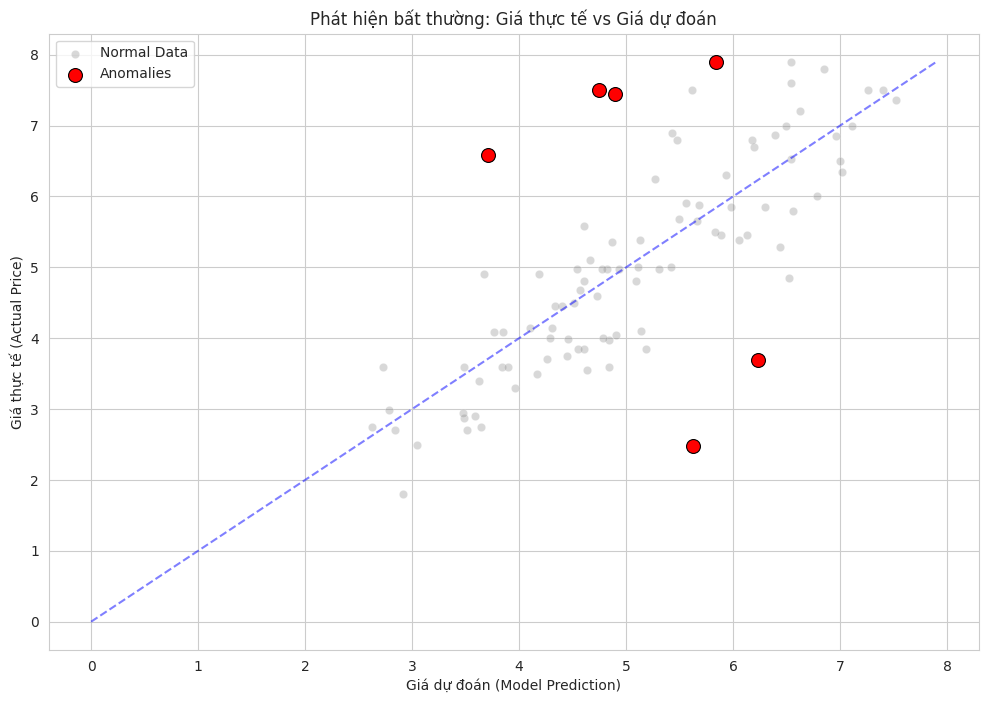

In [129]:
scatter_hightlight_outliers(df_anomalies, list_anomalies)

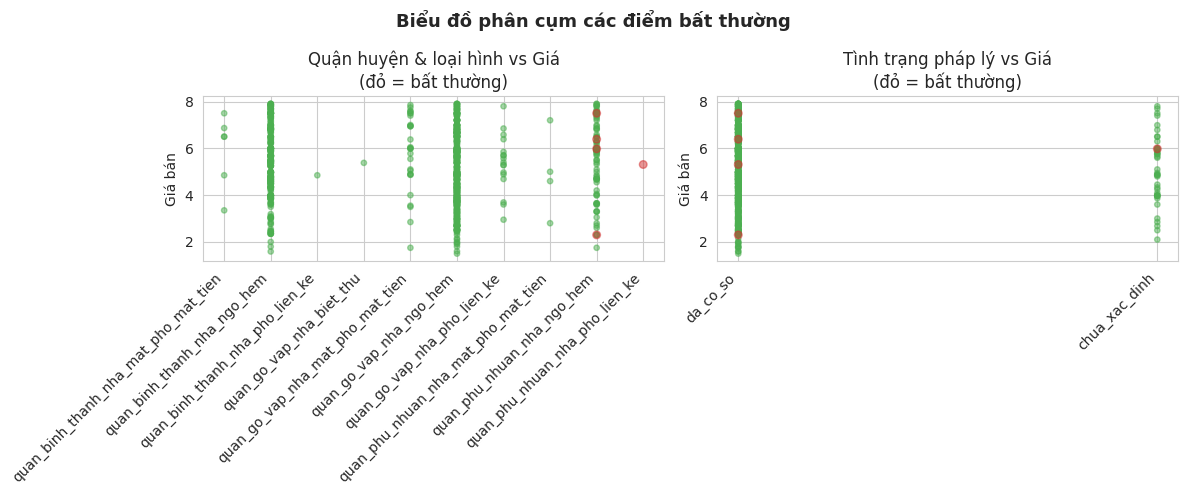

In [130]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Biểu đồ phân phối Residual-Z**

- Giúp quan sát ngưỡng cắt (threshold) mà tại đó một bản ghi bị coi là bất thường
- Đa số dữ liệu sẽ tập trung quanh vị trí 0. Những điểm nằm ngoài khoảng $[-3, 3]$ là những biến động cực đoan (outliers) về mặt thống kê.

In [131]:
def histplot_residual_z(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df.select('residual_z').toPandas(), kde=True, color='skyblue')

    # Vẽ đường ngưỡng (ví dụ z > 3 hoặc z < -3)
    plt.axvline(x=3, color='red', linestyle='--', label='Upper Threshold (3z)')
    plt.axvline(x=-3, color='red', linestyle='--', label='Lower Threshold (-3z)')

    plt.title("Phân phối của Residual-Z (Sai số chuẩn hóa)")
    plt.legend()
    plt.show()

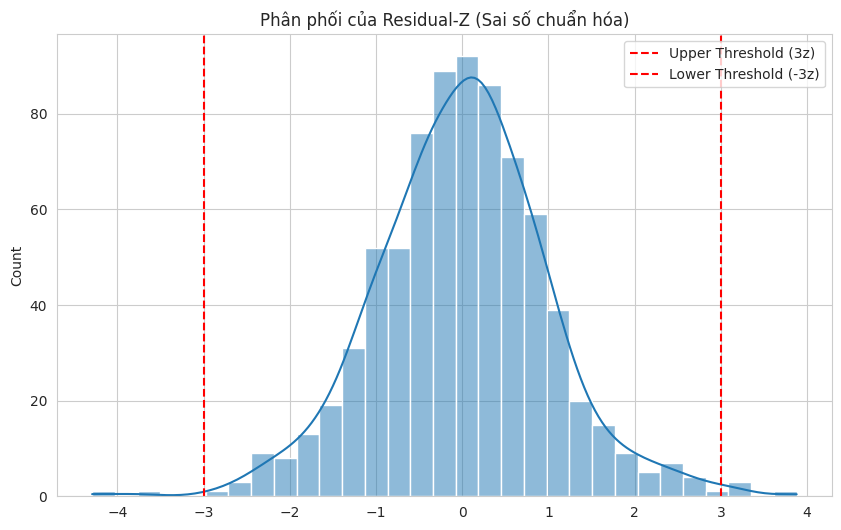

In [132]:
histplot_residual_z(df_anomalies)

### Phương Pháp 2: Vi Phạm Min/Max

### Ý tưởng
Thiết lập **khung giá sàn và giá trần** cho từng nhóm (quận + loại hình) dựa trên phân phối thực tế và giá lịch sử.  
Căn nhà có giá vượt ra ngoài ngưỡng → nghi ngờ **lỗi nhập liệu** hoặc **gian lận giá**.

### Công thức
$$Price_{min} = \mu - 3\sigma \quad , \quad Price_{max} = \mu + 3\sigma$$
$$S_{min\_max} = \begin{cases} 1 & \text{nếu } Price < Price_{min} \text{ hoặc } Price > Price_{max} \\ 0 & \text{nếu nằm trong khoảng an toàn} \end{cases}$$

Nhóm theo **(quận/ huyện + loại hình)** để đảm bảo so sánh công bằng — nhà mặt tiền Phú Nhuận và nhà hẻm Gò Vấp có mặt bằng giá rất khác nhau.

### Ưu và nhược điểm
**Ưu điểm:**

Công bằng: Không dùng chung một ngưỡng cho mọi loại nhà. Biệt thự 5 tỷ là "rẻ bất thường" nhưng căn hộ 5 tỷ là "bình thường".

Hiệu quả: Loại bỏ được các lỗi nhập liệu (nhập thiếu số 0 hoặc thừa số 0).

**Nhược điểm:**

Dễ mất dữ liệu hiếm: Những căn nhà siêu sang (Penthouse) hoặc nhà nát thực sự có thể bị đánh nhầm là bất thường nếu chúng nằm ở top 1% về giá.

In [133]:
def dectect_real_estate_anomalies_by_min_max(df, groupby_features, threshold_pr_min, threshold_pr_max):
    # Vi phạm min/max khi vượt ngưỡng giá lịch sử của phân khúc
    # Tính P1 (Min) và P99 (Max) cho mỗi loại hình
    mm_stats = df.groupBy(groupby_features).agg(
        F.percentile_approx("gia_ban", threshold_pr_min).alias("price_min"),
        F.percentile_approx("gia_ban", threshold_pr_max).alias("price_max")
    )
    df = df.join(mm_stats, on=groupby_features, how="left")
    df = df.withColumn("violate_min_max",
                       F.when((F.col("gia_ban") < F.col("price_min")) | (F.col("gia_ban") > F.col("price_max")), 1).otherwise(0))
    # Tạo 2 cột vi phạm riêng biệt
    df = df.withColumn("violate_min", F.when(F.col("gia_ban") < F.col("price_min"), 1).otherwise(0))
    df = df.withColumn("violate_max", F.when(F.col("gia_ban") > F.col("price_max"), 1).otherwise(0))
    return df

### **Thực thi Min-Max**

In [134]:
threshold_outlier_percent = 0.05
threshold_pr_min = 0.01
threshold_pr_max = 0.99
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "min_max": {
        "violate_min_max": 100
    }
}
methods_features = ["violate_min", "violate_max", "price_min", "price_max"]
methods_flags = ["violate_min_max"]

df_anomalies, list_anomalies = report_anomalies(df, groupby_features, methods, methods_features, methods_flags, threshold_outlier_percent, \
                 threshold_pr_min=threshold_pr_min, threshold_pr_max=threshold_pr_max)


Số lượng nhà bất thường phát hiện: 17
+-------+------------------+-----------+-----------+---------+---------+---------------+-------------------+---------------+--------------------+-------------+------------------+------------------+------------+------------+---------------------------+-------------------+---------------+-------------------------+---------------------+
|gia_ban|final_prediction  |violate_min|violate_max|price_min|price_max|violate_min_max|final_anomaly_score|quan_huyen     |loai_hinh           |dien_tich_dat|dien_tich_su_dung |chieu_ngang       |tong_so_tang|so_phong_ngu|giay_to_phap_ly            |tinh_trang_noi_that|dac_diem       |dia_chi_cu               |dia_chi_moi          |
+-------+------------------+-----------+-----------+---------+---------+---------------+-------------------+---------------+--------------------+-------------+------------------+------------------+------------+------------+---------------------------+-------------------+---------------+---

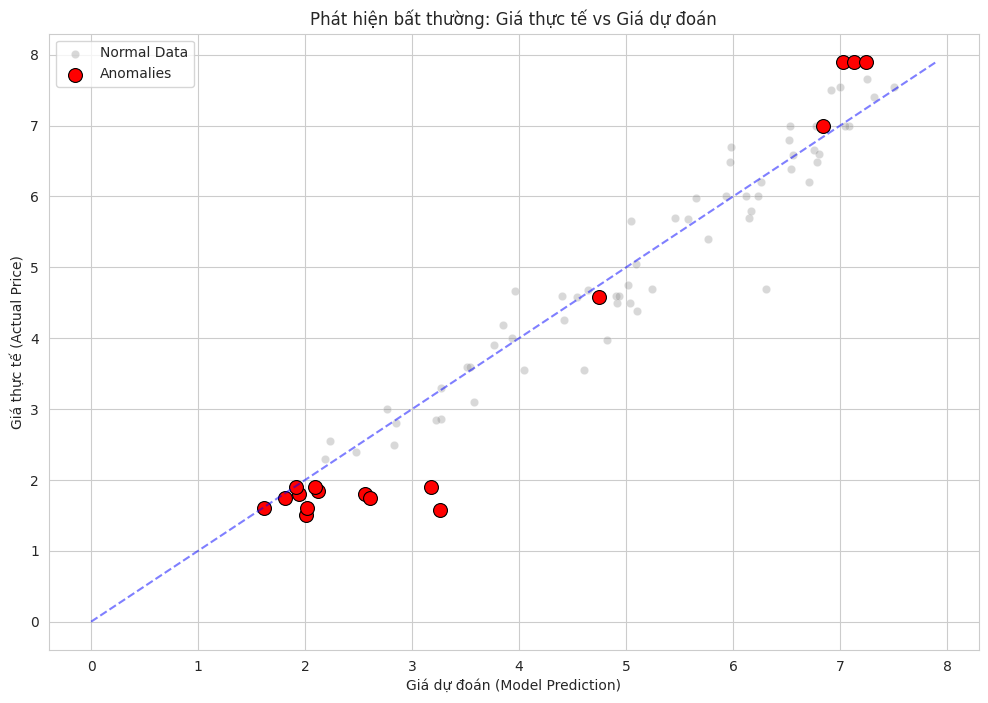

In [135]:
scatter_hightlight_outliers(df_anomalies, list_anomalies)

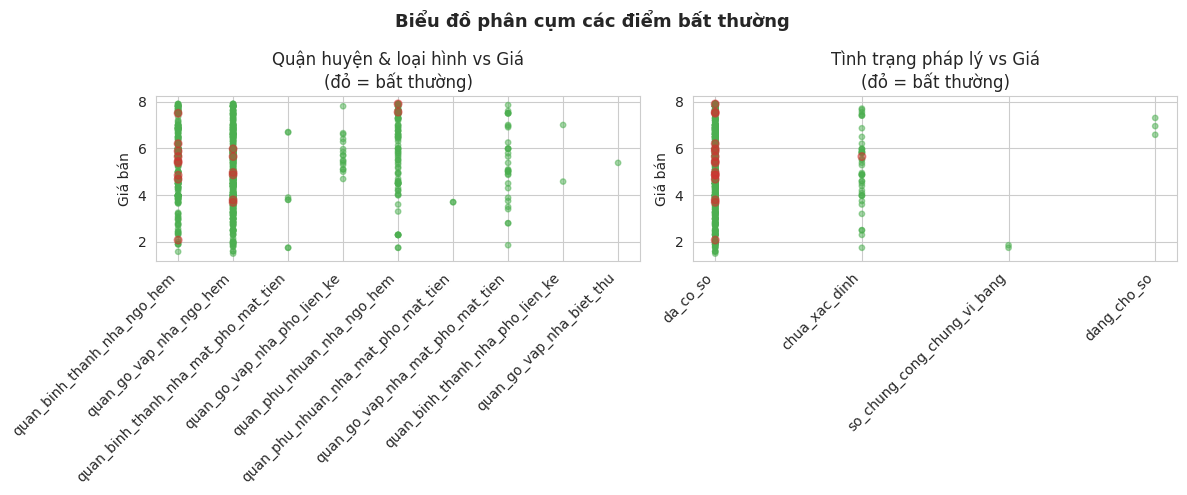

In [136]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

### Phương Pháp 3: Ngoài Khoảng P10-P90

### Ý tưởng
Xác định **"vùng giá phổ biến"** của thị trường — 80% giao dịch nằm trong [P10, P90].  
Căn nhà nằm ngoài khoảng này được gắn cờ kiểm tra, không bị ảnh hưởng bởi các giá trị cực đoan.

### Công thức
$$\text{Khoảng tin cậy} = [P_{10}, P_{90}]$$
$$d = \begin{cases} P_{10} - Price & \text{nếu } Price < P_{10} \\ Price - P_{90} & \text{nếu } Price > P_{90} \\ 0 & \text{nếu nằm trong khoảng} \end{cases}$$
$$S_{percentile} = \frac{d - d_{min}}{d_{max} - d_{min}}$$

**Ưu điểm so với Min/Max:** Không bị ảnh hưởng bởi outlier cực đoan khi tính ngưỡng.

In [137]:
def dectect_real_estate_anomalies_by_outside_conf(df, groupby_features, threshold_po_min, threshold_po_max):
    conf_stats = df.groupBy(groupby_features).agg(
        F.percentile_approx("gia_ban", threshold_po_min).alias(f"P{int(threshold_po_min * 100)}"),
        F.percentile_approx("gia_ban", threshold_po_max).alias(f"P{int(threshold_po_max * 100)}")
    )
    df = df.join(conf_stats, on=groupby_features, how="left")
    df = df.withColumn("outside_conf_flag",
                       F.when((F.col("gia_ban") < F.col("P10")) | (F.col("gia_ban") > F.col("P90")), 1).otherwise(0))
    df = df.withColumn("outside_conf_min", F.when(F.col("gia_ban") < F.col("P10"), 1).otherwise(0))
    df = df.withColumn("outside_conf_max", F.when(F.col("gia_ban") > F.col("P90"), 1).otherwise(0))
    return df

### **Thực thi ngoài khoảng tin cậy**

### Chọn ngoài khoảng tin cậy [P10, P90]

In [138]:
threshold_outlier_percent = 0.05    # 5%
threshold_po_min = 0.1              # P10
threshold_po_max = 0.9              # P90
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "outside_conf": {
        "outside_conf_flag": 100
    }
}
methods_features = ["outside_conf_min", "outside_conf_max"]
methods_flags = ["outside_conf_flag"]

# Using explicit keyword arguments to avoid positional mapping errors with optional parameters
df_anomalies, list_anomalies = report_anomalies(
                                                df=df,
                                                groupby_features=groupby_features,
                                                methods=methods,
                                                methods_features=methods_features,
                                                methods_flags=methods_flags,
                                                threshold_outlier_percent=threshold_outlier_percent,
                                                threshold_po_min=threshold_po_min,
                                                threshold_po_max=threshold_po_max
                                            )

Số lượng nhà bất thường phát hiện: 155
+-------+------------------+----------------+----------------+-----------------+-------------------+--------------+-----------+-------------+------------------+-----------------+------------+------------+---------------+-------------------+---------------+------------------------+----------------+
|gia_ban|final_prediction  |outside_conf_min|outside_conf_max|outside_conf_flag|final_anomaly_score|quan_huyen    |loai_hinh  |dien_tich_dat|dien_tich_su_dung |chieu_ngang      |tong_so_tang|so_phong_ngu|giay_to_phap_ly|tinh_trang_noi_that|dac_diem       |dia_chi_cu              |dia_chi_moi     |
+-------+------------------+----------------+----------------+-----------------+-------------------+--------------+-----------+-------------+------------------+-----------------+------------+------------+---------------+-------------------+---------------+------------------------+----------------+
|2.3    |3.6624011993408203|1               |0               |1 

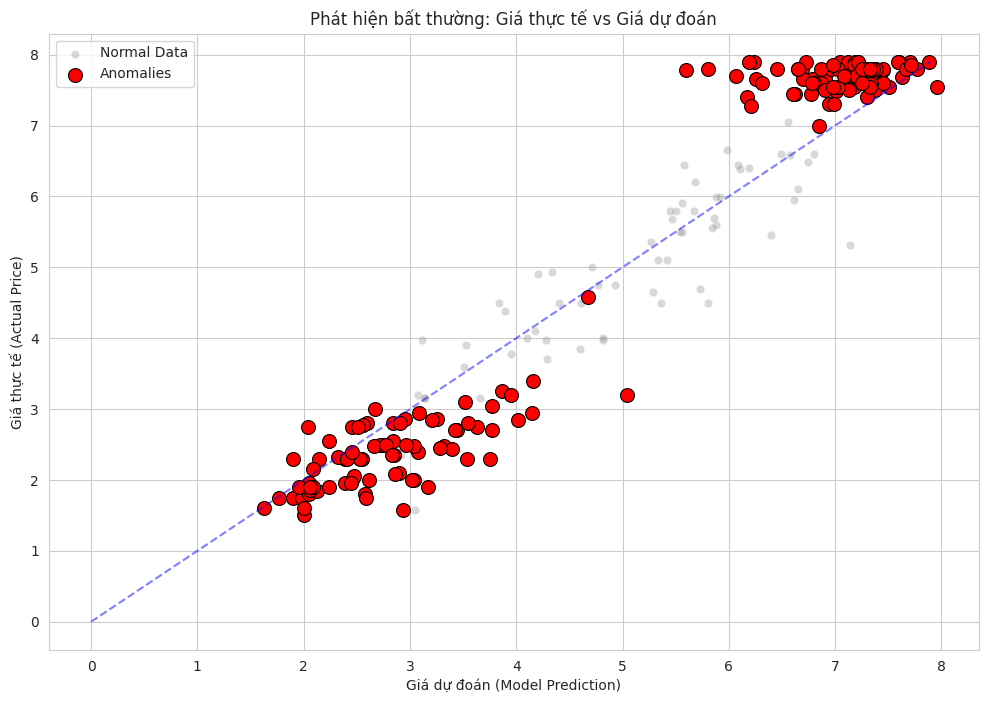

In [139]:
scatter_hightlight_outliers(df_anomalies, list_anomalies)

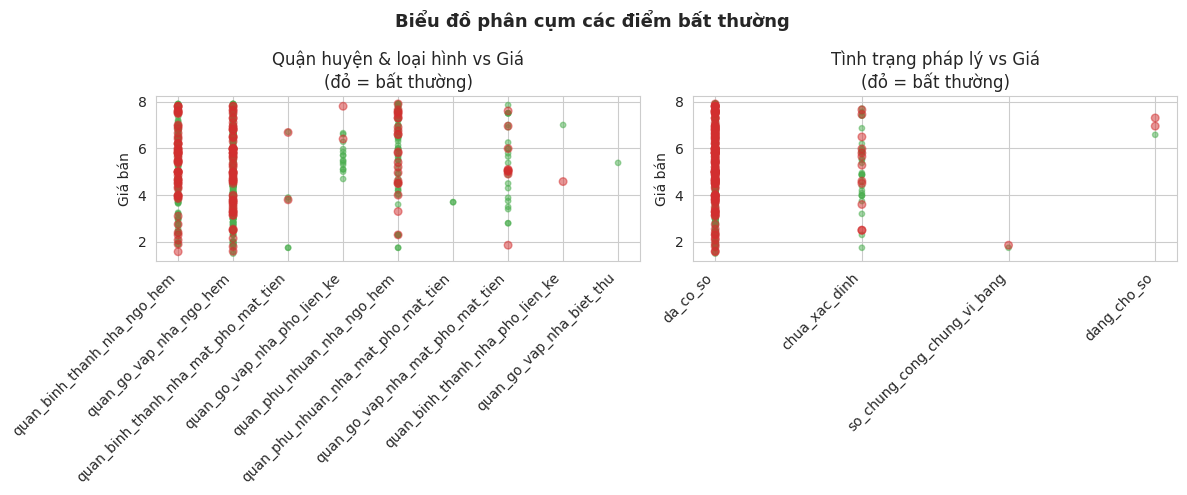

In [140]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

### Phương Pháp 4: Isolation Forest (Unsupervised ML)

### Ý tưởng
Thuật toán học máy **không giám sát** — phát hiện bất thường **đa chiều**, ví dụ nhà 20m² mà có 10 phòng ngủ.  
Các điểm bất thường dễ bị **"cô lập"** bằng ít bước phân chia cây hơn so với điểm bình thường.

Score càng thấp/âm → càng bất thường.

In [141]:
def dectect_real_estate_anomalies_by_isolation_forest(df, groupby_features, feature_cols, isf_contamination):
    # Spark's applyInPandas needs to map the input columns to the UDF input.
    df_prepared = df.withColumn("iforest_score", F.lit(0.0).cast(DoubleType())) \
                          .withColumn("is_anomaly_iforest", F.lit(0).cast(IntegerType()))

    # Define Output Schema (Matches the prepared df)
    output_schema = df_prepared.schema
    output_columns = output_schema.names

    # Define the Pandas UDF
    def iforest_udf(pdf: pd.DataFrame) -> pd.DataFrame:
        # Initial values are already there, but we ensure they are processed
        if len(pdf) >= 10:
            X = pdf[feature_cols].fillna(0)
            model = IsolationForest(contamination=isf_contamination, random_state=42)
            model.fit(X)

            pdf['iforest_score'] = model.decision_function(X).astype(float)
            preds = model.predict(X)
            pdf['is_anomaly_iforest'] = [1 if p == -1 else 0 for p in preds]
        else:
            pdf['iforest_score'] = 0.0
            pdf['is_anomaly_iforest'] = 0

        # Strictly return columns in the same order as output_schema
        return pdf[output_columns]

    # Apply groupBy and Pandas UDF
    result_df = df_prepared.groupBy(groupby_features) \
                           .applyInPandas(iforest_udf, schema=output_schema) \
                           .orderBy(F.col("iforest_score").asc())

    return result_df

In [142]:
threshold_percent = 0.05
isf_contamination = 0.05
feature_cols = ["dien_tich_su_dung", "gia_ban", "final_prediction"]
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "isolation_forest": {
        "is_anomaly_iforest": 100 # Trọng số cho điểm số tổng hợp
    }
}
methods_features = ["iforest_score"]
methods_flags = ["is_anomaly_iforest"]

df_anomalies, list_anomalies = report_anomalies(df, groupby_features, methods, methods_features, methods_flags, threshold_percent, \
                                                feature_cols=feature_cols, isf_contamination=isf_contamination)


Số lượng nhà bất thường phát hiện: 40
+-------+------------------+----------------------+------------------+-------------------+--------------+---------------+-------------+------------------+------------------+------------+------------+---------------+-------------------+---------------+------------------------+--------------------+
|gia_ban|final_prediction  |iforest_score         |is_anomaly_iforest|final_anomaly_score|quan_huyen    |loai_hinh      |dien_tich_dat|dien_tich_su_dung |chieu_ngang       |tong_so_tang|so_phong_ngu|giay_to_phap_ly|tinh_trang_noi_that|dac_diem       |dia_chi_cu              |dia_chi_moi         |
+-------+------------------+----------------------+------------------+-------------------+--------------+---------------+-------------+------------------+------------------+------------+------------+---------------+-------------------+---------------+------------------------+--------------------+
|6.59   |3.696425437927246 |-4.0638386562896756E-4|1                

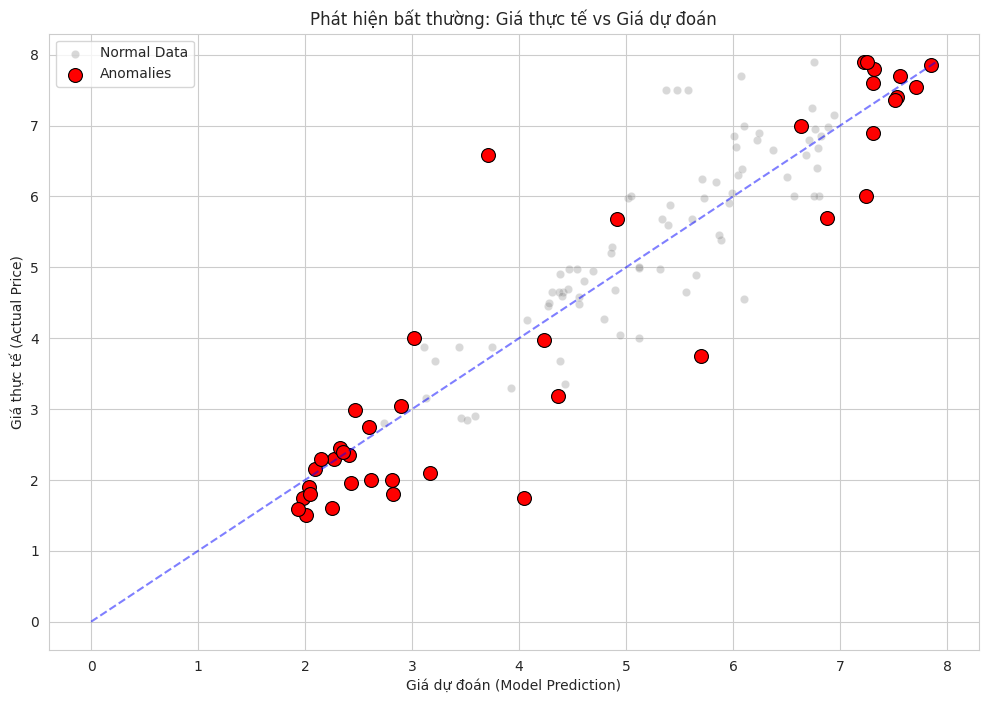

In [143]:
scatter_hightlight_outliers(df_anomalies, list_anomalies)

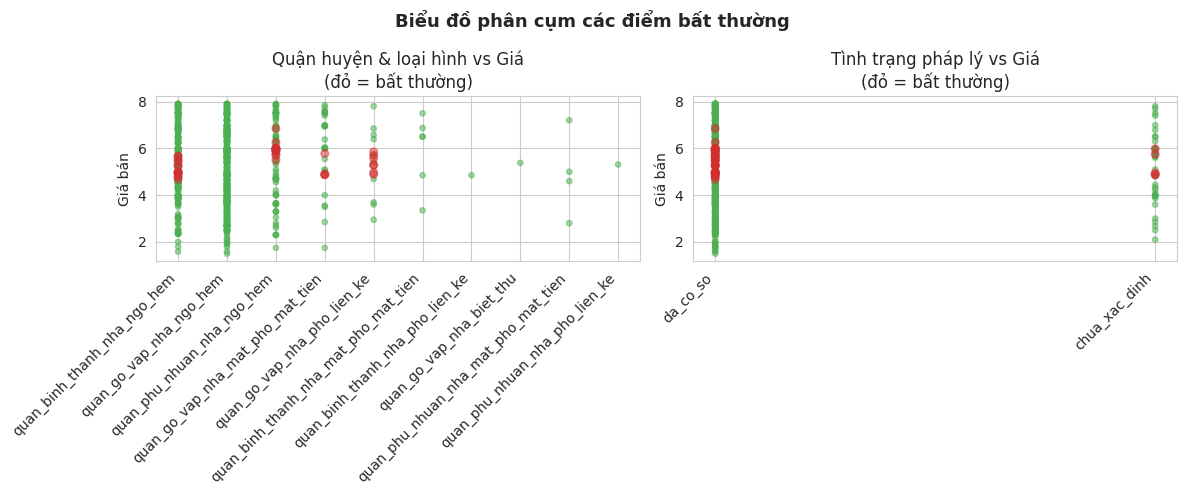

In [144]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Tổng hợp**

### Trọng số: Residual-z (30%), Vi phạm Min/Max (25%), Ngoài khoảng tin cậy (15%), Isolation Forest (30%)

In [145]:
threshold_outlier_percent = 0.05    # 5%  - Lấy 5% top bất thường nhất
threshold_pr_min = 0.01             # P1  - Min-Max
threshold_pr_max = 0.99             # P99 - Min-Max
threshold_po_min = 0.1              # P10 - Ngoài khoảng tin cậy
threshold_po_max = 0.9              # P90 - Ngoài khoảng tin cậy
isf_contamination = 0.05
feature_cols = ["dien_tich_su_dung", "gia_ban", "final_prediction"]
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "residual_z": {
        "violate_residual_z": 30
    },
    "min_max": {
        "violate_min_max": 25
    },
    "outside_conf": {
        "outside_conf_flag": 15
    },
    "isolation_forest": {
        "is_anomaly_iforest": 30
    }
}
methods_features = ["residual", "violate_min", "violate_max", "price_min", "price_max", "outside_conf_min", "outside_conf_max", "iforest_score"]
methods_flags = ["violate_residual_z", "violate_min_max", "outside_conf_flag", "is_anomaly_iforest"]

df_anomalies, list_anomalies = report_anomalies(df, groupby_features, methods, methods_features, methods_flags=methods_flags, \
                                                threshold_outlier_percent=threshold_outlier_percent, \
                                                threshold_pr_min=threshold_pr_min, threshold_pr_max=threshold_pr_max, \
                                                threshold_po_min=threshold_po_min, threshold_po_max=threshold_po_max, \
                                                feature_cols=feature_cols, isf_contamination=isf_contamination)

Số lượng nhà bất thường phát hiện: 45
+-------+------------------+---------------------+-----------+-----------+---------+---------+----------------+----------------+---------------------+------------------+---------------+-----------------+------------------+-------------------+---------------+---------------+-------------+------------------+------------------+------------+------------+---------------+-------------------+---------------+-------------------------+---------------------+
|gia_ban|final_prediction  |residual             |violate_min|violate_max|price_min|price_max|outside_conf_min|outside_conf_max|iforest_score        |violate_residual_z|violate_min_max|outside_conf_flag|is_anomaly_iforest|final_anomaly_score|quan_huyen     |loai_hinh      |dien_tich_dat|dien_tich_su_dung |chieu_ngang       |tong_so_tang|so_phong_ngu|giay_to_phap_ly|tinh_trang_noi_that|dac_diem       |dia_chi_cu               |dia_chi_moi          |
+-------+------------------+---------------------+------

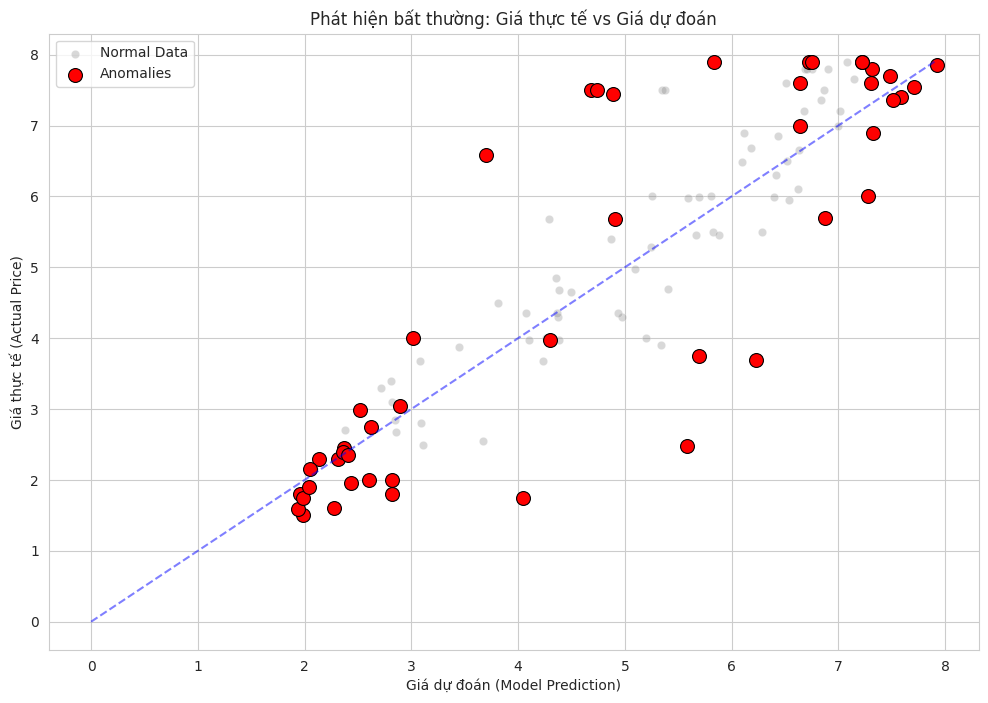

In [146]:
scatter_hightlight_outliers(df_anomalies, list_anomalies)

**Giải thích biểu đồ**
- **Vùng giá quá rẻ (Dưới đường chéo)**: Các chấm đỏ nằm xa phía dưới đường nét đứt màu xanh là những căn nhà có giá rao bán thấp hơn rất nhiều so với giá trị thực mà mô hình tính toán được. Đây có thể là những cơ hội đầu tư hoặc lỗi nhập liệu.
- **Vùng giá quá đắt (Trên đường chéo)**: Các chấm đỏ nằm vọt lên trên là những căn nhà "ngáo giá" hoặc có những đặc điểm cực kỳ cao cấp mà các biến số hiện tại (diện tích, số phòng) chưa phản ánh hết.


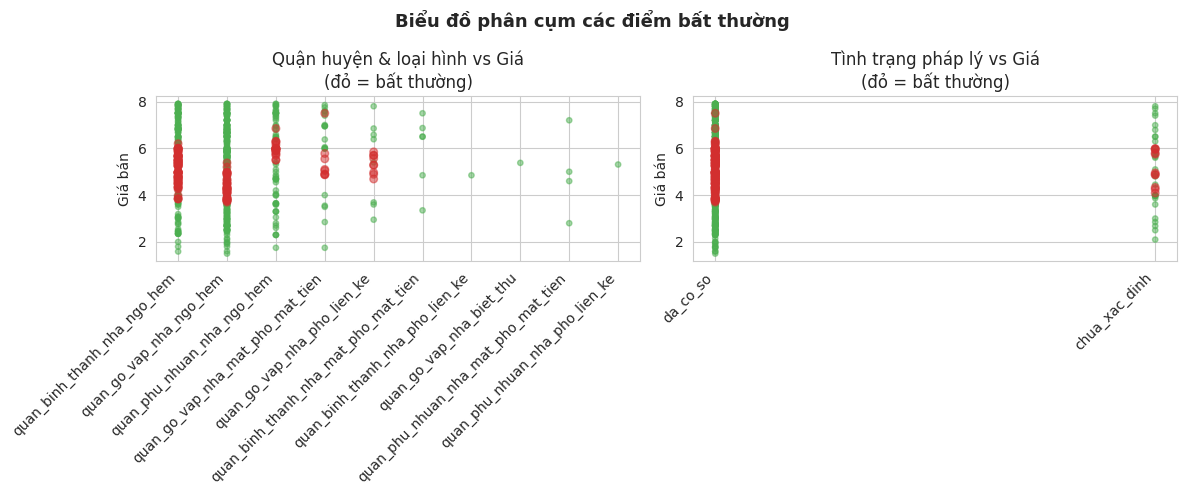

In [147]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Quận Gò Vấp** có nhiều dữ liệu bất thường nhất, trải dài ở nhiều phân khúc, suy ra:
- Mặt chủ quan: vấn đề nhập liệu có sai sót
- Mặt khách quan: thị trường nhà ở tại quận này có biến động lớn --> cơ hội đầu tư lớn với nhiều căn nhà có biên độ chênh lệch giá cao

## **Kết luận**

### Tổng kết 4 phương pháp

| Phương pháp | Ưu điểm | Nhược điểm | Trọng số |
|---|---|---|:---:|
| **Residual-Z** | Chính xác cho từng căn, dựa trên model | Cần model dự đoán tốt | 0.30 |
| **Min/Max** | Đơn giản, lọc nhanh lỗi nhập liệu | Không linh hoạt theo thị trường | 0.25 |
| **P10-P90** | Khách quan theo thị trường, robust với outlier | Có thể bỏ sót nhà quá đặc biệt | 0.15 |
| **Isolation Forest** | Phát hiện bất thường đa chiều | Khó giải thích lý do bất thường | 0.30 |

### Ứng dụng thực tế ngay lập tức
- **Rất bất thường (Top 5%)** → Kiểm duyệt ngay, yêu cầu người đăng giải thích
- **Bất thường (Top 10%)** → Gắn cờ cảnh báo, theo dõi thêm
- **Bình thường** → Cho phép đăng bình thường

### Định hướng tiếp theo
- EDA data + tunning kỹ hơn để giảm MAE, tăng R² của XGBoost → Residual-Z chính xác hơn
- Bổ sung features (Fearture Seclection): vd: khoảng cách đến trung tâm, tiện ích xung quanh
- Điều chỉnh trọng số w dựa trên thống kê hoặc machine learning
- Mở rộng dữ liệu các quận khác để P10-P90 và Min/Max chính xác hơn
- Kiểm tra thủ công: Lấy **tieu_de** hoặc **mo_ta** của các căn nhà có final_anomaly_score cao để xem thực tế.
- Kiểm tra giá min max lịch sử của phân khúc giá nhà theo quan_huyen + loai_hinh
- Kiểm tra các yếu tố gây ảnh hưởng khiến giá trở thành outlier: số lượng nhà theo phân khúc giá cao rất ít? lỗi nhập liệu? đẩy giá do đầu cơ ? tình trạng pháp lý (vd: nhà VIP nhưng vướng pháp lý khiến giá bị định giá thấp)
- Nắm bắt cơ hội đầu tư từ những căn có biên độ giá cao, v.v...